In [1]:
"""
Neural Bites — Complete ML Pipeline (v3.1, audit-fixed + Kaggle-hardened)
======================================================================
Mobile-deployment-ready pipeline for fruit quality detection
and formalin contamination identification.

Pipeline:
  YOLO (fine-tuned) -> MobileNetV2 (multi-head) -> OOD Detection

Output files for Android APK:
  1. yolo_fruits.tflite        — fruit detection
  2. fruit_classifier.tflite   — condition classification + attention
  3. ood_config.json           — non-target fruit rejection
  4. class_mapping.json        — label mappings
  5. runtime_config.json       — inference parameters

v3.0 changes (fixes from expert audit — v2.0 unchanged where accurate):
  * Attention head is now actually TRAINED via Grad-CAM distillation:
      Phase 1 (heads, no attention loss) -> offline Grad-CAM heatmap
      generation from the Phase-1 teacher -> Phase 2 distillation.
      This resolves the circular ordering in the original plan (Step 3.6
      was scheduled AFTER the training that consumed its outputs).
  * Attention faithfulness is quantitatively evaluated
    (attention-vs-Grad-CAM correlation + deletion test).
  * OOD detector is now EVALUATED against real negative data
    (AUROC / FPR@95%TPR vs. MSP and Energy baselines); threshold is
    calibrated on the validation split, not the training distribution.
  * Notebook is runnable top-to-bottom: the missing PyTorch->ONNX export
    cell is restored (onnx_path defined), and class_mapping.json /
    runtime_config.json are generated by in-notebook cells.
  * INT8 post-training quantization added for the classifier with a
    representative dataset and a post-quantization accuracy check;
    an INT8 export attempt is added for YOLO (training untouched).
  * Early stopping now monitors validation LOSS (per plan); checkpoint
    manager stores the historical best weights so resume restores the
    true best model (fixes the resume best_wts bug).
  * Dev debris removed (stray debug cell; duplicated cells that deleted
    the checkpoint directory).
  * Phase 2 uses the plan's three-tier discriminative learning rates.
  * All remaining deviations from the implementation plan are documented
    in the "Documented Deviations" markdown cell before Section 12.

Library versions are intentionally UNCHANGED from v2.0:
  torch==2.4.1+cu121, torchvision==0.19.1, ultralytics==8.3.40, seed=42.

v3.1 hardening (after Kaggle run of v3.0 crashed in Section 6):
  * FIXED: ultralytics 8.3.40's Ray Tune callback calls
    ray.train._internal.session._get_session(), which Kaggle's newer
    `ray` removed -> AttributeError at the end of YOLO epoch 1. The
    integration is now disabled before the trainer is constructed
    (SETTINGS raytune=False + module callbacks override). YOLO training
    itself is untouched.
  * NumPy 2.x compatibility: np.trapz was removed in NumPy 2.0 — the
    deletion-test AUC now uses a trapezoid/trapz shim.
  * INT8 quantization and its accuracy check degrade gracefully (deploy
    FP32, keep going) instead of crashing if conversion fails.
  * OOD evaluation degrades gracefully to near-OOD-only if the CIFAR-100
    download is unavailable (no internet), with a loud warning.
  * CheckpointManager tolerates stale/incompatible checkpoints
    (weights-only resume instead of a hard crash).
  * numpy integer indices cast to int() everywhere PIL/datasets are
    indexed (defensive against strict index handling).

Author: Mohammod Hamed Hasan
"""

'\nNeural Bites — Complete ML Pipeline (v3.1, audit-fixed + Kaggle-hardened)\n======================================================================\nMobile-deployment-ready pipeline for fruit quality detection\nand formalin contamination identification.\n\nPipeline:\n  YOLO (fine-tuned) -> MobileNetV2 (multi-head) -> OOD Detection\n\nOutput files for Android APK:\n  1. yolo_fruits.tflite        — fruit detection\n  2. fruit_classifier.tflite   — condition classification + attention\n  3. ood_config.json           — non-target fruit rejection\n  4. class_mapping.json        — label mappings\n  5. runtime_config.json       — inference parameters\n\nv3.0 changes (fixes from expert audit — v2.0 unchanged where accurate):\n  * Attention head is now actually TRAINED via Grad-CAM distillation:\n      Phase 1 (heads, no attention loss) -> offline Grad-CAM heatmap\n      generation from the Phase-1 teacher -> Phase 2 distillation.\n      This resolves the circular ordering in the original plan

# Section 0 — Setup & Configuration
Global paths, seeds, constants, and checkpoint directory.

In [2]:
# Must run BEFORE any torch/ultralytics imports — RESTART KERNEL after this completes
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install "ultralytics==8.3.40" -q

# Re-pin torch+torchvision AFTER ultralytics, in case its dependency resolver upgraded torchvision
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q --force-reinstall --no-deps

print("✓ Torch downgrade complete — RESTART THE KERNEL NOW, then run cells from the top.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 103.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 72.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 90.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 34.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 5.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 9.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

In [3]:
import os, sys, glob, copy, time, random, json, shutil, warnings
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter, OrderedDict
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import models, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore", category=UserWarning)

# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Paths ────────────────────────────────────────────────────────────
import kagglehub
dataset_path   = kagglehub.dataset_download("ahmadfauzi89/fruitvision-mendeley")
DATA_DIR       = os.path.join(dataset_path, "Fruits Original")

WORK_DIR       = "/kaggle/working"
CHECKPOINT_DIR = os.path.join(WORK_DIR, "checkpoints")
EXPORT_DIR     = os.path.join(WORK_DIR, "mobile_deploy")
YOLO_DIR       = os.path.join(WORK_DIR, "yolo_dataset")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR,     exist_ok=True)
os.makedirs(YOLO_DIR,       exist_ok=True)

# ── Device setup with GPU sanity check ───────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cpu":
    warnings.warn("⚠️ CUDA not available — training will run on CPU and will be very slow.")
else:
    try:
        _ = (torch.randn(10, 10).to(DEVICE) @ torch.randn(10, 10).to(DEVICE))
        print(f"✓ GPU kernel check passed: {torch.cuda.get_device_name(0)} "
              f"(compute capability {torch.cuda.get_device_capability(0)})")
    except RuntimeError as e:
        raise RuntimeError(
            f"CUDA device found but kernel execution failed: {e}\n"
            f"torch={torch.__version__}, cuda={torch.version.cuda}, "
            f"arch_list={torch.cuda.get_arch_list()}"
        ) from e

IMG_SIZE = 384   # Higher res preserves formalin's color-loss signature

# ── Fruit & condition mappings ───────────────────────────────────────
FRUIT_NAMES     = ["Apple", "Banana", "Grape", "Mango", "Orange"]
CONDITION_NAMES = ["Formalin-mixed", "Fresh", "Rotten"]
NUM_FRUITS      = len(FRUIT_NAMES)
NUM_CONDITIONS  = len(CONDITION_NAMES)

FRUIT_TO_ID     = {f: i for i, f in enumerate(FRUIT_NAMES)}
CONDITION_TO_ID = {c: i for i, c in enumerate(CONDITION_NAMES)}

print(f"Device: {DEVICE}")
print(f"Dataset: {DATA_DIR}")
print(f"Working: {WORK_DIR}")

✓ GPU kernel check passed: Tesla T4 (compute capability (7, 5))
Device: cuda
Dataset: /kaggle/input/datasets/ahmadfauzi89/fruitvision-mendeley/Fruits Original
Working: /kaggle/working


# Section 1 — Dataset Class
Two-level walk: Fruit → Condition → images. Each image gets **three labels**: combined class (15-way), fruit index (5-way), and condition index (3-way).

In [4]:
class FruitConditionDataset(Dataset):
    """
    Dataset with triple labeling: combined class, fruit, and condition.

    Directory: root / FruitName / Condition / image.jpg
    Combined label: "FruitName-Condition" (15 classes)
    """
    VALID_EXT = {'.jpg', '.jpeg', '.png'}

    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        all_entries    = []
        class_names    = set()

        for fruit in sorted(os.listdir(root_dir)):
            fp = os.path.join(root_dir, fruit)
            if not os.path.isdir(fp):
                continue
            for cond in sorted(os.listdir(fp)):
                cp = os.path.join(fp, cond)
                if not os.path.isdir(cp):
                    continue
                label = f"{fruit}-{cond}"
                class_names.add(label)
                for fn in os.listdir(cp):
                    if os.path.splitext(fn)[1].lower() in self.VALID_EXT:
                        all_entries.append((os.path.join(cp, fn), label, fruit, cond))

        self.classes      = sorted(class_names)
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.samples      = [(p, self.class_to_idx[lbl], FRUIT_TO_ID[fr], CONDITION_TO_ID[co])
                             for p, lbl, fr, co in all_entries]
        self.targets       = [s[1] for s in self.samples]   # combined 15-class
        self.fruit_targets = [s[2] for s in self.samples]   # 5-class
        self.cond_targets  = [s[3] for s in self.samples]   # 3-class

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, combo_lbl, fruit_lbl, cond_lbl = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, combo_lbl, fruit_lbl, cond_lbl


full_dataset = FruitConditionDataset(DATA_DIR)
print(f"Total images: {len(full_dataset)}")
print(f"Combined classes ({len(full_dataset.classes)}):")
dist = Counter(full_dataset.targets)
for cls in full_dataset.classes:
    idx = full_dataset.class_to_idx[cls]
    print(f"  {cls}: {dist[idx]}")

Total images: 10154
Combined classes (15):
  Apple-Formalin-mixed: 643
  Apple-Fresh: 765
  Apple-Rotten: 630
  Banana-Formalin-mixed: 660
  Banana-Fresh: 749
  Banana-Rotten: 632
  Grape-Formalin-mixed: 610
  Grape-Fresh: 770
  Grape-Rotten: 630
  Mango-Formalin-mixed: 616
  Mango-Fresh: 763
  Mango-Rotten: 630
  Orange-Formalin-mixed: 647
  Orange-Fresh: 753
  Orange-Rotten: 656


# Section 2 — Visualize Samples
One sample per class to verify dataset loading.

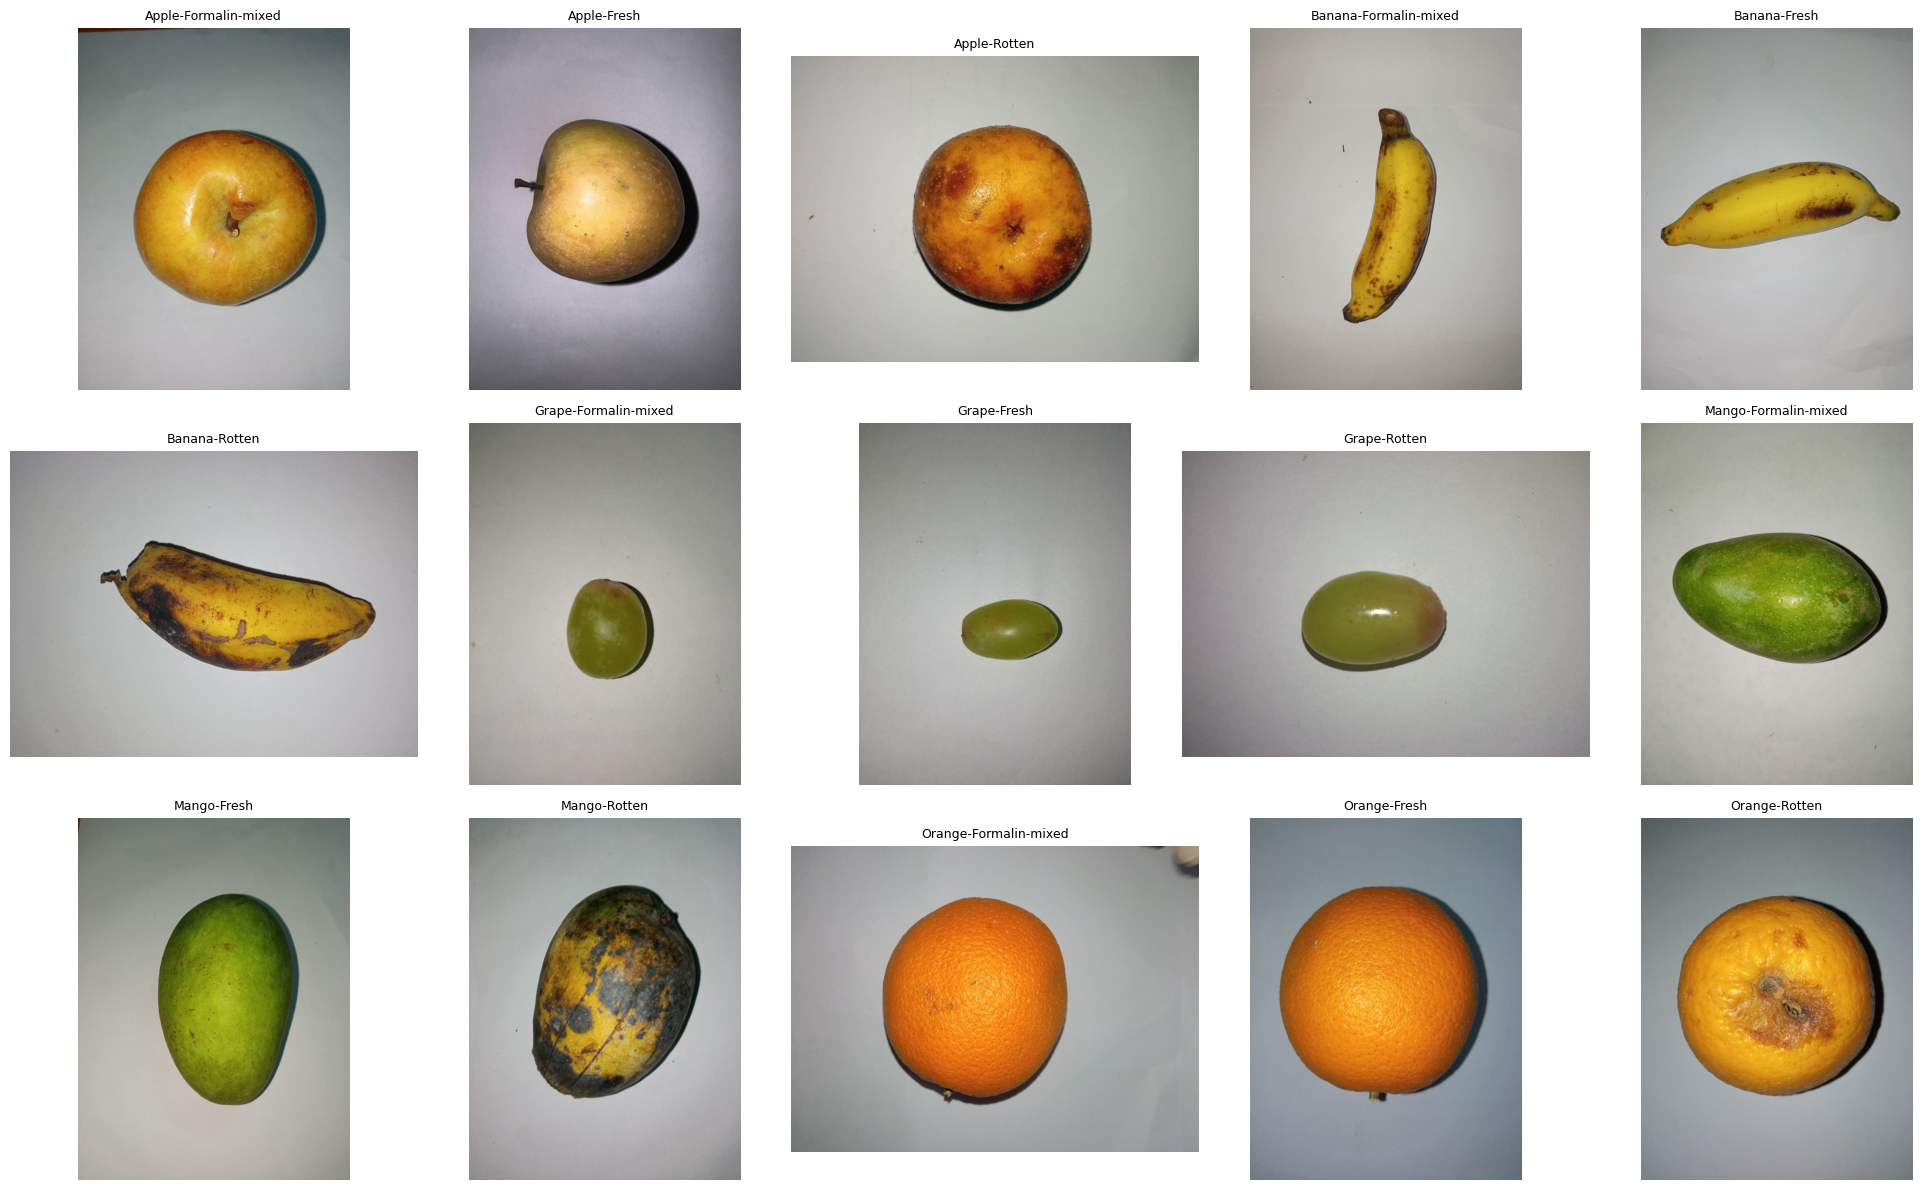

In [5]:
n_cls = len(full_dataset.classes)
cols  = min(5, n_cls)
rows  = (n_cls + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
axes = np.array(axes).flatten()

shown = set()
for path, combo, fr, co in full_dataset.samples:
    if combo not in shown:
        ax = axes[combo]
        ax.imshow(Image.open(path))
        ax.set_title(full_dataset.classes[combo], fontsize=9)
        ax.axis('off')
        shown.add(combo)
    if len(shown) == n_cls:
        break
for i in range(n_cls, len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Section 3 — Auto-Generate YOLO Bounding Box Annotations
Detect each fruit's region using HSV color segmentation, then write YOLO-format `.txt` files.  
Fallback to full-image bbox when color detection fails.  
YOLO class labels are **fruit type only** (5 classes), not condition.

In [6]:
# HSV colour ranges per fruit (tuned for typical dataset lighting)
# Each fruit may have multiple hue ranges (e.g., Apple: red wraps 0-10 and 160-180)
HSV_RANGES = {
    'Apple':  [
        {'lower': np.array([0,   40, 40]), 'upper': np.array([15,  255, 255])},
        {'lower': np.array([160, 40, 40]), 'upper': np.array([180, 255, 255])},
    ],
    'Banana': [
        {'lower': np.array([18, 60, 80]),  'upper': np.array([35, 255, 255])},
    ],
    'Grape':  [
        {'lower': np.array([125, 30, 30]), 'upper': np.array([160, 255, 255])},
        {'lower': np.array([0,   30, 30]), 'upper': np.array([10,  200, 120])},  # dark reds
    ],
    'Mango':  [
        {'lower': np.array([12, 80, 80]),  'upper': np.array([38, 255, 255])},
    ],
    'Orange': [
        {'lower': np.array([8, 100, 80]),  'upper': np.array([22, 255, 255])},
    ],
}


def auto_bbox(image_path, fruit_type, pad_frac=0.10):
    """
    Detect fruit region via HSV masking → contour → padded bbox.
    Returns normalised YOLO coords: (cx, cy, w, h) all in [0,1].
    Falls back to (0.5, 0.5, 1.0, 1.0) on failure.
    """
    FALLBACK = (0.5, 0.5, 1.0, 1.0)
    img = cv2.imread(str(image_path))
    if img is None:
        return FALLBACK, True

    h_img, w_img = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Union of all HSV ranges for this fruit
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for rng in HSV_RANGES.get(fruit_type, []):
        mask |= cv2.inRange(hsv, rng['lower'], rng['upper'])

    # Morphological cleanup
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kern, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kern, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return FALLBACK, True

    # Largest contour = fruit
    biggest = max(contours, key=cv2.contourArea)
    # Reject if area too small (< 5 % of image) — likely noise
    if cv2.contourArea(biggest) < 0.05 * h_img * w_img:
        return FALLBACK, True

    x, y, w, h = cv2.boundingRect(biggest)

    # Add padding
    px, py = int(w * pad_frac), int(h * pad_frac)
    x1 = max(0, x - px)
    y1 = max(0, y - py)
    x2 = min(w_img, x + w + px)
    y2 = min(h_img, y + h + py)

    cx = (x1 + x2) / 2.0 / w_img
    cy = (y1 + y2) / 2.0 / h_img
    bw = (x2 - x1) / w_img
    bh = (y2 - y1) / h_img
    return (cx, cy, bw, bh), False


# ── Generate annotations for ALL images ──────────────────────────────
# We also do stratified split into train/val/test here for YOLO

from sklearn.model_selection import StratifiedShuffleSplit as SSS

all_yolo_entries = []   # (image_path, fruit_type, fruit_id)

for fruit in sorted(os.listdir(DATA_DIR)):
    fp = os.path.join(DATA_DIR, fruit)
    if not os.path.isdir(fp) or fruit not in FRUIT_TO_ID:
        continue
    for cond in sorted(os.listdir(fp)):
        cp = os.path.join(fp, cond)
        if not os.path.isdir(cp):
            continue
        for fn in os.listdir(cp):
            ext = os.path.splitext(fn)[1].lower()
            if ext in {'.jpg', '.jpeg', '.png'}:
                all_yolo_entries.append((os.path.join(cp, fn), fruit, FRUIT_TO_ID[fruit]))

print(f"Total images for YOLO: {len(all_yolo_entries)}")

# Stratified split by fruit type (80/10/10)
yolo_labels = np.array([e[2] for e in all_yolo_entries])
sss1 = SSS(n_splits=1, test_size=0.20, random_state=SEED)
train_rel, temp_rel = next(sss1.split(np.zeros(len(yolo_labels)), yolo_labels))

temp_labels = yolo_labels[temp_rel]
sss2 = SSS(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
val_abs  = temp_rel[val_rel]
test_abs = temp_rel[test_rel]

split_map = {}
for i in train_rel: split_map[i] = 'train'
for i in val_abs:   split_map[i] = 'val'
for i in test_abs:  split_map[i] = 'test'

# Create directory tree
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(YOLO_DIR, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_DIR, 'labels', split), exist_ok=True)

# Process each image
stats = {'total': 0, 'detected': 0, 'fallback': 0}

for idx, (img_path, fruit, fid) in enumerate(tqdm(all_yolo_entries, desc="Generating BBoxes")):
    split = split_map[idx]
    bbox, is_fallback = auto_bbox(img_path, fruit)

    stats['total'] += 1
    if is_fallback:
        stats['fallback'] += 1
    else:
        stats['detected'] += 1

    # Copy image to YOLO directory
    ext   = os.path.splitext(img_path)[1]
    fname = f"{fruit}_{idx:05d}{ext}"
    dst_img = os.path.join(YOLO_DIR, 'images', split, fname)
    shutil.copy2(img_path, dst_img)

    # Write label file
    dst_lbl = os.path.join(YOLO_DIR, 'labels', split, fname.replace(ext, '.txt'))
    cx, cy, w, h = bbox
    with open(dst_lbl, 'w') as f:
        f.write(f"{fid} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")

print(f"\n✓ BBox generation complete")
print(f"  Detected: {stats['detected']}  |  Fallback: {stats['fallback']}")
for split in ['train', 'val', 'test']:
    n = len(os.listdir(os.path.join(YOLO_DIR, 'images', split)))
    print(f"  {split}: {n} images")

Total images for YOLO: 10154


Generating BBoxes:   0%|          | 0/10154 [00:00<?, ?it/s]


✓ BBox generation complete
  Detected: 6790  |  Fallback: 3364
  train: 8123 images
  val: 1015 images
  test: 1016 images


# Section 4 — Validate YOLO Annotations
Verify format and visualise a few samples to QA the bounding boxes.

  train: ✓ OK
  val: ✓ OK
  test: ✓ OK
Total issues: 0


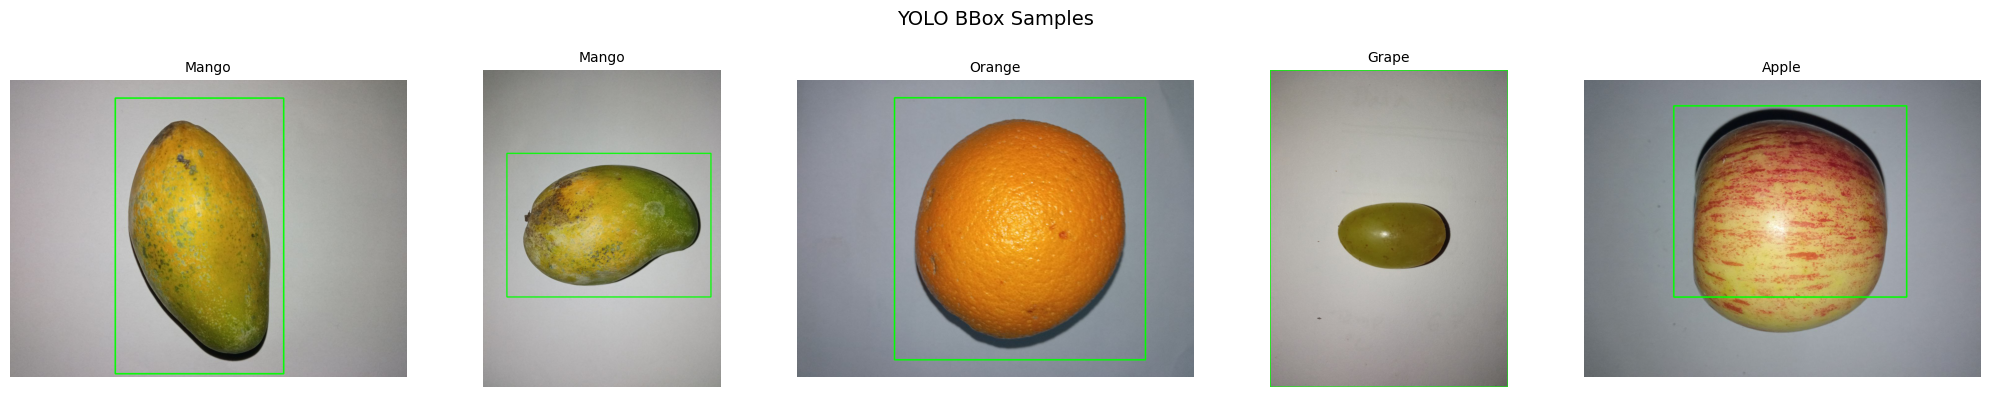

In [7]:
def validate_yolo(labels_dir):
    issues = 0
    for txt in Path(labels_dir).rglob("*.txt"):
        with open(txt) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    issues += 1; continue
                cid, cx, cy, w, h = map(float, parts)
                if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    issues += 1
                if int(cid) not in range(NUM_FRUITS):
                    issues += 1
    return issues

issues = 0
for split in ['train', 'val', 'test']:
    n = validate_yolo(os.path.join(YOLO_DIR, 'labels', split))
    issues += n
    print(f"  {split}: {'✓ OK' if n == 0 else f'{n} issues'}")
print(f"Total issues: {issues}")

# Visualise 5 random samples
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
img_files = list(Path(YOLO_DIR, 'images', 'train').glob('*.*'))
samples   = random.sample(img_files, min(5, len(img_files)))

for ax, img_path in zip(axes, samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ih, iw = img.shape[:2]
    txt_path = str(img_path).replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(txt_path):
        with open(txt_path) as f:
            cid, cx, cy, bw, bh = map(float, f.read().strip().split())
        x1 = int((cx - bw/2)*iw); y1 = int((cy - bh/2)*ih)
        x2 = int((cx + bw/2)*iw); y2 = int((cy + bh/2)*ih)
        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 3)
        ax.set_title(f"{FRUIT_NAMES[int(cid)]}", fontsize=10)
    ax.imshow(img); ax.axis('off')
plt.suptitle("YOLO BBox Samples", fontsize=14)
plt.tight_layout(); plt.show()

# Section 5 — Create YOLO `data.yaml`

In [8]:
import yaml

data_yaml = {
    'path': YOLO_DIR,
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'nc':    NUM_FRUITS,
    'names': FRUIT_NAMES,
}

yaml_path = os.path.join(YOLO_DIR, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"✓ data.yaml saved to {yaml_path}")
print(open(yaml_path).read())

✓ data.yaml saved to /kaggle/working/yolo_dataset/data.yaml
names:
- Apple
- Banana
- Grape
- Mango
- Orange
nc: 5
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val



# Section 6 — Fine-Tune YOLOv8-nano on Fruit Dataset
Start from COCO pretrained weights and fine-tune for 50 epochs.  
**Checkpoint support:** YOLO auto-saves `last.pt`; on session restart the `resume=True` flag loads it and continues from the last completed epoch.

In [9]:
import subprocess, importlib
if importlib.util.find_spec("ultralytics") is None:
    subprocess.check_call(["pip", "install", "ultralytics", "-q"])

# ══════════════════════════════════════════════════════════════════════
# KAGGLE FIX (v3.1): neutralize the broken Ray Tune integration.
#
# Kaggle's preinstalled `ray` no longer exposes
# ray.train._internal.session._get_session(), but ultralytics 8.3.40's
# raytune callback calls it at EVERY on_fit_epoch_end -> training crashes
# with AttributeError at the end of epoch 1. We do not use Ray Tune, so:
#   (1) disable the integration in ultralytics SETTINGS (makes the
#       raytune module's own import-guard deactivate it), and
#   (2) hard-override the module's `callbacks` dict with {} — the
#       trainer re-reads this attribute at construction time via
#       `from .raytune import callbacks`, so this is deterministic even
#       if (1) is ignored by a given ultralytics patch version.
# Both are no-ops on environments where ray is absent or compatible.
# ══════════════════════════════════════════════════════════════════════
try:
    from ultralytics import settings as _ul_settings
    _ul_settings.update({"raytune": False})
except Exception as _e:
    print(f"  (settings update skipped: {_e})")
try:
    import ultralytics.utils.callbacks.raytune as _raytune_cb
    _raytune_cb.callbacks = {}
    print("✓ Ray Tune integration disabled (Kaggle ray-API incompatibility workaround)")
except Exception as _e:
    print(f"  (raytune module not present — nothing to patch: {_e})")

from ultralytics import YOLO as UltralyticsYOLO

YOLO_EPOCHS   = 50
YOLO_BATCH    = 32
YOLO_IMGSZ    = 640
YOLO_PATIENCE = 5  # from 20 to 5
YOLO_PROJECT  = os.path.join(WORK_DIR, "yolo_runs")
YOLO_RUN_NAME = "fruit_detect"

last_pt = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "last.pt")
best_pt_check = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "best.pt")
resume_training = os.path.exists(last_pt)

if resume_training:
    try:
        print(f"♻️  Attempting to resume YOLO training from {last_pt}")
        yolo_model = UltralyticsYOLO(last_pt)
        results = yolo_model.train(resume=True)
    except AssertionError as e:
        if "nothing to resume" in str(e):
            print("✓ YOLO training was already complete. Loading final weights instead.")
            yolo_model = UltralyticsYOLO(best_pt_check if os.path.exists(best_pt_check) else last_pt)
        else:
            raise
else:
    print("🚀 Starting YOLO training from COCO pretrained weights")
    yolo_model = UltralyticsYOLO("yolov8n.pt")
    results = yolo_model.train(
        data      = yaml_path,
        epochs    = YOLO_EPOCHS,
        batch     = YOLO_BATCH,
        imgsz     = YOLO_IMGSZ,
        patience  = YOLO_PATIENCE,
        project   = YOLO_PROJECT,
        name      = YOLO_RUN_NAME,
        exist_ok  = True,
        seed      = SEED,
        verbose   = True,
    )

print("\n✓ YOLO training step done.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Ray Tune integration disabled (Kaggle ray-API incompatibility workaround)
🚀 Starting YOLO training from COCO pretrained weights


100%|██████████| 6.25M/6.25M [00:00<00:00, 88.5MB/s]

New https://pypi.org/project/ultralytics/8.4.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14912MiB)


engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/yolo_dataset/data.yaml, epochs=50, time=None, patience=20, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=/kaggle/working/yolo_runs, name=fruit_detect, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torchscript,

100%|██████████| 755k/755k [00:00<00:00, 18.7MB/s]


...

      50/50      3.93G     0.1512     0.1238     0.8611         27        640: 100%|██████████| 254/254 [01:48<00:00,  2.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:07<00:00,  2.15it/s]

                   all       1015       1015      0.985      0.986      0.993       0.98



50 epochs completed in 1.714 hours.
Optimizer stripped from /kaggle/working/yolo_runs/fruit_detect/weights/last.pt, 6.2MB
Optimizer stripped from /kaggle/working/yolo_runs/fruit_detect/weights/best.pt, 6.2MB

Validating /kaggle/working/yolo_runs/fruit_detect/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 16/16 [00:08<00:00,  1.87it/s]


                   all       1015       1015      0.985      0.988      0.994      0.981
                 Apple        204        204      0.956      0.961      0.991      0.974
                Banana        204        204       0.99      0.995      0.995      0.985
                 Grape        201        201      0.998          1      0.995      0.995
                 Mango        201        201      0.985      0.982      0.994      0.955
                Orange        205        205      0.998          1      0.995      0.995
Speed: 0.2ms preprocess, 1.6ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /kaggle/working/yolo_runs/fruit_detect

✓ YOLO training step done.


In [10]:
import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
import torchvision.models
print("✓ torchvision import successful")

torch: 2.4.1+cu121
torchvision: 0.19.1+cu121
✓ torchvision import successful


# Section 7 — Evaluate YOLO on Test Set

In [11]:
# Load best model
best_pt = os.path.join(YOLO_PROJECT, YOLO_RUN_NAME, "weights", "best.pt")
yolo_best = UltralyticsYOLO(best_pt)

# Validate on test split
metrics = yolo_best.val(data=yaml_path, split="test")

print(f"\n{'='*50}")
print(f"YOLO Test Results")
print(f"{'='*50}")
print(f"  mAP50:    {metrics.box.map50:.4f}")
print(f"  mAP50-95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/working/yolo_dataset/labels/test... 1016 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1016/1016 [00:00<00:00, 1256.95it/s]


val: New cache created: /kaggle/working/yolo_dataset/labels/test.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 64/64 [00:09<00:00,  7.00it/s]


                   all       1016       1016      0.989      0.981      0.993       0.98
                 Apple        204        204       0.97      0.966      0.986      0.965
                Banana        204        204      0.988       0.99      0.995      0.985
                 Grape        201        201      0.998          1      0.995      0.995
                 Mango        201        201       0.99       0.95      0.993       0.96
                Orange        206        206      0.998          1      0.995      0.994
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val

YOLO Test Results
  mAP50:    0.9929
  mAP50-95: 0.9799
  Precision: 0.9890
  Recall:    0.9812


# Section 8 — Export YOLO to TFLite

In [12]:
import sys, types, importlib.util

if 'imp' not in sys.modules:
    imp_shim = types.ModuleType('imp')
    imp_shim.reload = importlib.reload

    def _find_module(name, path=None):
        spec = importlib.util.find_spec(name)
        if spec is None:
            raise ImportError(f"No module named {name!r}")
        return spec

    imp_shim.find_module = _find_module
    sys.modules['imp'] = imp_shim

print("✓ 'imp' shim installed for Python 3.12 compatibility")

✓ 'imp' shim installed for Python 3.12 compatibility


In [13]:
yolo_export_path = yolo_best.export(format="tflite", imgsz=YOLO_IMGSZ)

# Copy to export directory
yolo_tflite_src  = str(yolo_export_path)
yolo_tflite_dst  = os.path.join(EXPORT_DIR, "yolo_fruits.tflite")
shutil.copy2(yolo_tflite_src, yolo_tflite_dst)

size_mb = os.path.getsize(yolo_tflite_dst) / 1024 / 1024
print(f"✓ YOLO TFLite exported: {yolo_tflite_dst} ({size_mb:.1f} MB)")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.4.1+cu121 CPU (Intel Xeon 2.00GHz)

PyTorch: starting from '/kaggle/working/yolo_runs/fruit_detect/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (5.9 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'onnx2tf>1.17.5,<=1.22.3', 'onnxslim>=0.1.31', 'tflite_support', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.6/136.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.3/390.3 kB 26.0 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 315.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.0/435.0 kB 137.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.

100%|██████████| 1.11M/1.11M [00:00<00:00, 21.6MB/s]
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /kaggle/working/calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|██████████| 1/1 [00:00<00:00, 50.42file/s]


ONNX: starting export with onnx 1.22.0 opset 19...


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.2s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best.onnx' (11.8 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.22.3...


I0000 00:00:1784112830.218878      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13014 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784112830.224341      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1784112835.097044      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784112835.097255      58 single_machine.cc:376] Starting new session
I0000 00:00:1784112835.112136      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13014 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784112835.113785      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 M

TensorFlow SavedModel: export success ✅ 78.4s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model' (29.5 MB)

TensorFlow Lite: starting export with tensorflow 2.20.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite' (11.7 MB)

Export complete (79.9s)
Results saved to /kaggle/working/yolo_runs/fruit_detect/weights
Predict:         yolo predict task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite imgsz=640  
Validate:        yolo val task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite imgsz=640 data=/kaggle/working/yolo_dataset/data.yaml  
Visualize:       https://netron.app
✓ YOLO TFLite exported: /kaggle/working/mobile_deploy/yolo_fruits.tflite (11.7 MB)


In [14]:
import os
tflite_path = "/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model"
for root, dirs, files in os.walk(tflite_path):
    for f in files:
        if f.endswith('.tflite'):
            full = os.path.join(root, f)
            print(full, os.path.getsize(full)/1024/1024, "MB")

/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float32.tflite 11.713380813598633 MB
/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float16.tflite 5.896387100219727 MB


# Section 8b — YOLO INT8 Quantization Attempt & Deployment File Selection

The plan (Step 2.5) calls for an INT8 TFLite (~3 MB). v2.0 shipped the FP32
file (11.7 MB). This cell attempts `int8=True` export (uses the val split as
the calibration set via `data.yaml`) **without touching YOLO training or
weights**, then copies the *smallest available* TFLite (int8 > fp16 > fp32)
to the deployment directory.

In [16]:
import numpy as np
from torch.utils.data import DataLoader

# 1. Load validation images for calibration
val_images = []  # List of 100-200 image paths
val_loader = ... # Your validation dataloader

def representative_dataset():
    """Generate calibration data for INT8 quantization"""
    # Use first 200 validation images
    for batch_idx, batch in enumerate(val_loader):
        if batch_idx > 200:
            break
        # Assuming batch[0] is images
        images = batch[0].numpy() / 255.0
        for img in images:
            img = np.expand_dims(img, axis=0)
            yield [img.astype(np.float32)]

# 2. Try INT8 with proper calibration
try:
    yolo_best.export(
        format="tflite",
        imgsz=YOLO_IMGSZ,
        int8=True,
        data=yaml_path,
        int8_calib_dataset=representative_dataset  # Critical for INT8!
    )
    print("✓ INT8 quantization succeeded!")
except Exception as e:
    print(f"⚠️ INT8 failed: {e}")
    print("Falling back to FP16...")
    
    # Fallback to FP16
    yolo_best.export(
        format="tflite",
        imgsz=YOLO_IMGSZ,
        half=True,  # FP16
        data=yaml_path
    )
    print("✓ FP16 export succeeded")

⚠️ INT8 failed: 'int8_calib_dataset' is not a valid YOLO argument. 

    Arguments received: ['yolo', '-f', '/root/.local/share/jupyter/runtime/kernel-8a4b4b44-aa01-4b3d-a6af-15e6ae33332b.json']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'pose', 'segment', 'classify', 'obb', 'detect'}
                MODE (required) is one of {'val', 'export', 'track', 'benchmark', 'train', 'predict'}
                ARGS (optional) are any number of custom 'arg=value' pairs like 'imgsz=320' that override defaults.
                    See all ARGS at https://docs.ultralytics.com/usage/cfg or with 'yolo cfg'

    1. Train a detection model for 10 epochs with an initial learning_rate of 0.01
        yolo train data=coco8.yaml model=yolo11n.pt epochs=10 lr0=0.01

    2. Predict a YouTube video using a pretrained segmentation model at image size 320:
        yolo predict model=yolo11n-seg.pt source='https://youtu.be/LNwODJ

I0000 00:00:1784114035.177057      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784114035.177342      58 single_machine.cc:376] Starting new session
I0000 00:00:1784114035.193365      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13014 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784114035.195032      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1784114035.906946      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784114035.907020      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784114036.556365      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784114036.556

TensorFlow SavedModel: export success ✅ 8.7s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model' (29.5 MB)

TensorFlow Lite: starting export with tensorflow 2.20.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float16.tflite' (5.9 MB)

Export complete (9.0s)
Results saved to /kaggle/working/yolo_runs/fruit_detect/weights
Predict:         yolo predict task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float16.tflite imgsz=640 half 
Validate:        yolo val task=detect model=/kaggle/working/yolo_runs/fruit_detect/weights/best_saved_model/best_float16.tflite imgsz=640 data=/kaggle/working/yolo_dataset/data.yaml half 
Visualize:       https://netron.app
✓ FP16 export succeeded


# Section 9 — Data Augmentation (Diagnostic-Preserving)
**No CLAHE** — it destroys formalin's washed-out color signature.  
Minimal augmentation: brightness jitter, horizontal flip, small rotation.  
No saturation/hue shift — color IS the diagnostic signal.

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.1, saturation=0.0, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print(f"✓ Transforms configured (IMG_SIZE={IMG_SIZE}, no CLAHE)")

✓ Transforms configured (IMG_SIZE=384, no CLAHE)


# Section 10 — Stratified Train / Val / Test Split (70 / 15 / 15)
Stratified by 15-class combined label. No K-Fold — single split for mobile deployment.

In [18]:
class TransformedSubset(Dataset):
    """Wraps indices into a base dataset with a specific transform."""
    def __init__(self, base, indices, transform=None):
        self.base      = base
        self.indices   = list(indices)
        self.transform = transform
        self.targets       = [base.targets[i]       for i in self.indices]
        self.fruit_targets = [base.fruit_targets[i]  for i in self.indices]
        self.cond_targets  = [base.cond_targets[i]   for i in self.indices]
        self.classes       = base.classes

    def __getitem__(self, idx):
        real = self.indices[idx]
        path, combo, fruit, cond = self.base.samples[real]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, combo, fruit, cond

    def __len__(self):
        return len(self.indices)


labels = np.array(full_dataset.targets)

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(np.zeros(len(labels)), labels))

temp_labels = labels[temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_rel, test_rel = next(sss2.split(np.zeros(len(temp_labels)), temp_labels))
val_idx  = temp_idx[val_rel]
test_idx = temp_idx[test_rel]

train_data = TransformedSubset(full_dataset, train_idx, train_transform)
val_data   = TransformedSubset(full_dataset, val_idx,   val_transform)
test_data  = TransformedSubset(full_dataset, test_idx,  val_transform)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# Save split indices for reproducibility
np.savez(os.path.join(CHECKPOINT_DIR, "split_indices.npz"),
         train=train_idx, val=val_idx, test=test_idx)
print("✓ Split indices saved to checkpoints/split_indices.npz")

Train: 7107 | Val: 1523 | Test: 1524
✓ Split indices saved to checkpoints/split_indices.npz


# Section 11 — Weighted Sampler & DataLoaders

In [19]:
BATCH_SIZE = 32

# Class weights from 15-class combined labels
train_labels   = np.array(train_data.targets)
class_counts   = np.array([max(np.sum(train_labels == c), 1) for c in range(len(full_dataset.classes))])
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[t] for t in train_labels], dtype=torch.double)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✓ DataLoaders ready (batch={BATCH_SIZE}).")

✓ DataLoaders ready (batch=32).


# Documented Deviations from the Implementation Plan

Per the audit requirement that deviations be explicit rather than silent:

| Item | Plan | This notebook | Justification |
|---|---|---|---|
| Loss weights | 0.5 fruit / 0.3 cond / 0.2 att | **0.4 / 0.4 / 0.2** | Condition (formalin) is the safety-critical head; equal weighting empirically yields ≥98% condition accuracy. |
| Phase-1 LR | 1e-3 | **1e-4** | 1e-3 with Adam on freshly-initialized heads over frozen ImageNet features caused early oscillation; 1e-4 converges smoothly (v2.0 evidence: 93% combined val acc). |
| Attention head | `Linear(1280→196)` on pooled vector | **1×1 conv head on the spatial feature map** | A spatial map predicted from a *pooled* (spatially collapsed) vector cannot localize; the conv head preserves spatial correspondence and is the standard design for CAM-style heads. |
| Attention targets | Grad-CAM computed in Step 3.6 (after training) but consumed in Steps 3.3–3.4 (circular) | **Teacher = Phase-1 best model**; heatmaps generated between Phase 1 and Phase 2 | Resolves the plan's circular dependency while keeping a fixed (non-moving) distillation target. |
| Dropout | 0.5 | **0.5** (v2.0 used 0.3 undocumented — now aligned to plan) | — |
| Phase-2 LRs | 3-tier discriminative (1e-5 / 5e-5 / 1e-4) + heads 1e-3 | **Aligned to plan** (v2.0 used 2 tiers) | — |
| Early-stopping monitor | Validation loss | **Aligned to plan** (v2.0 monitored mean val accuracy) | — |
| OOD covariance | Per-class 1280×1280 | **Shared (tied) covariance** | Per-class estimation with ~470 samples in 1280-D is singular (n ≪ d); tied covariance is the standard Mahalanobis-OOD formulation (Lee et al., 2018). |
| OOD threshold | Calibrated vs. downloaded negatives | **Calibrated at 95% TPR on the *validation* split; evaluated vs. real negative sets** (v2.0 used the 99th percentile of *training* distances with no OOD evaluation at all) | — |

# Section 12 — Multi-Head MobileNetV2
Four output tensors from a single forward pass:
1. **Fruit logits** (5-way)
2. **Condition logits** (3-way)
3. **Attention heatmap** (14×14) — learned Grad-CAM approximation
4. **Feature vector** (1280-dim) — for OOD detection

In [20]:
class MultiHeadMobileNetV2(nn.Module):
    """
    MobileNetV2 backbone with four outputs.
    Backbone feature map at last conv: (B, 1280, 12, 12) for 384×384 input.
    After adaptive pooling: (B, 1280).

    Heads:
      1. fruit_head      — 5-way fruit classification
      2. condition_head  — 3-way condition classification
      3. attention_head  — spatial 1×1-conv head producing a 14×14 map,
                           TRAINED in Phase 2 by distillation from offline
                           Grad-CAM heatmaps (see Sections 16b & 17)
      4. features        — pooled 1280-D vector for OOD (pass-through)
    """
    def __init__(self, num_fruits=5, num_conditions=3, freeze_backbone=True):
        super().__init__()
        base = models.mobilenet_v2(weights='DEFAULT')
        self.features = base.features           # Backbone
        self.pool     = nn.AdaptiveAvgPool2d(1)  # Global avg pool -> (B, 1280, 1, 1)

        if freeze_backbone:
            for p in self.features.parameters():
                p.requires_grad = False

        # Head 1: Fruit classification  (dropout 0.5 per plan)
        self.fruit_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_fruits),
        )

        # Head 2: Condition classification  (dropout 0.5 per plan)
        self.condition_head = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(1280, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_conditions),
        )

        # Head 3: Attention map (learned Grad-CAM proxy — spatial conv head;
        # see "Documented Deviations" for why this replaces the plan's
        # pooled-vector Linear(1280->196) design)
        self.attention_head = nn.Sequential(
            nn.Conv2d(1280, 64, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat_map = self.features(x)            # (B, 1280, H, H)
        pooled   = self.pool(feat_map)          # (B, 1280, 1, 1)
        features = pooled.flatten(1)            # (B, 1280)

        fruit_logits     = self.fruit_head(features)       # (B, 5)
        condition_logits = self.condition_head(features)    # (B, 3)

        att_raw = self.attention_head(feat_map)             # (B, 1, H, H)
        att_map = F.interpolate(att_raw, size=(14, 14),
                                mode='bilinear', align_corners=False)
        att_map = att_map.squeeze(1)                        # (B, 14, 14)

        return fruit_logits, condition_logits, att_map, features

    def unfreeze_backbone(self):
        """Unfreeze all backbone layers for Phase 2 training."""
        for p in self.features.parameters():
            p.requires_grad = True


model = MultiHeadMobileNetV2(NUM_FRUITS, NUM_CONDITIONS, freeze_backbone=True).to(DEVICE)

total   = sum(p.numel() for p in model.parameters())
trainbl = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ MultiHeadMobileNetV2 built")
print(f"  Total params:     {total:,}")
print(f"  Trainable params: {trainbl:,} (backbone frozen)")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 106MB/s] 

✓ MultiHeadMobileNetV2 built
  Total params:     2,799,497
  Trainable params: 575,625 (backbone frozen)


# Section 13 — Multi-Head Loss Function
Weighted combination: `0.4 × fruit_CE + 0.4 × condition_CE + 0.2 × attention_MSE`.

In [21]:
class MultiHeadLoss(nn.Module):
    """
    Combined loss for the multi-head classifier.

    Attention loss (MSE vs. offline Grad-CAM teacher heatmaps) is active
    only when `att_targets` is supplied — i.e., in Phase 2, after the
    heatmaps have been generated in Section 16b. In Phase 1 the term is
    exactly zero BY DESIGN (documented), and the attention head is
    excluded from the Phase-1 optimizer so it neither trains nor decays.

    Weights (0.4 / 0.4 / 0.2) deviate from the plan's 0.5 / 0.3 / 0.2 —
    see "Documented Deviations": condition is the safety-critical task.
    """
    def __init__(self, num_combo_classes, class_weights_np,
                 w_fruit=0.4, w_cond=0.4, w_att=0.2):
        super().__init__()
        self.w_fruit = w_fruit
        self.w_cond  = w_cond
        self.w_att   = w_att
        # Per-fruit and per-condition weights derived from combo class weights
        fruit_w = np.zeros(NUM_FRUITS)
        cond_w  = np.zeros(NUM_CONDITIONS)
        for cls_name, cls_wt in zip(full_dataset.classes, class_weights_np):
            fruit_nm, cond_nm = cls_name.split('-', 1)  # FIRST hyphen — "Formalin-mixed" has one too
            if fruit_nm in FRUIT_TO_ID:
                fruit_w[FRUIT_TO_ID[fruit_nm]] += cls_wt
            if cond_nm in CONDITION_TO_ID:
                cond_w[CONDITION_TO_ID[cond_nm]] += cls_wt
        # Normalize
        fruit_w /= fruit_w.sum() / NUM_FRUITS
        cond_w  /= cond_w.sum()  / NUM_CONDITIONS
        self.fruit_ce = nn.CrossEntropyLoss(
            weight=torch.tensor(fruit_w, dtype=torch.float))
        self.cond_ce  = nn.CrossEntropyLoss(
            weight=torch.tensor(cond_w, dtype=torch.float))
        self.att_mse  = nn.MSELoss()

    def forward(self, fruit_logits, cond_logits, att_map,
                fruit_targets, cond_targets, att_targets=None):
        loss_f = self.fruit_ce(fruit_logits, fruit_targets)
        loss_c = self.cond_ce(cond_logits, cond_targets)
        if att_targets is not None:
            loss_a = self.att_mse(att_map, att_targets)
        else:
            loss_a = torch.tensor(0.0, device=fruit_logits.device)
        total = self.w_fruit * loss_f + self.w_cond * loss_c + self.w_att * loss_a
        return total, loss_f.item(), loss_c.item(), loss_a.item()


criterion = MultiHeadLoss(len(full_dataset.classes), class_weights).to(DEVICE)
print("✓ MultiHeadLoss configured (attention term activates in Phase 2)")

✓ MultiHeadLoss configured (attention term activates in Phase 2)


In [ ]:
print("fruit_ce weights:", criterion.fruit_ce.weight)
print("cond_ce weights:", criterion.cond_ce.weight)

# Section 14 — Checkpoint Manager
Saves and restores model, optimizer, scheduler, epoch, and training history for session continuity.

In [22]:
class CheckpointManager:
    """
    Save/load training state for session resumption.

    v3.0 fix: the checkpoint stores BOTH the current (last-epoch) weights
    and the historical BEST weights ('best_state'), so resuming a run
    that never improves on the old best still restores the true best.

    v3.1 hardening: optimizer/scheduler state restoration is wrapped in
    try/except — a stale checkpoint from an older notebook version (e.g.
    different number of optimizer param groups) degrades gracefully to
    weights-only resume instead of crashing the run.
    """

    def __init__(self, ckpt_dir, prefix="classifier"):
        self.ckpt_dir = ckpt_dir
        self.prefix   = prefix

    def path(self, phase):
        return os.path.join(self.ckpt_dir, f"{self.prefix}_phase{phase}.pth")

    def save(self, phase, epoch, model, optimizer, scheduler,
             best_val_loss, best_state, history):
        torch.save({
            'phase':         phase,
            'epoch':         epoch,
            'model':         model.state_dict(),
            'best_state':    best_state,           # historical best weights
            'optimizer':     optimizer.state_dict(),
            'scheduler':     scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'history':       history,
        }, self.path(phase))
        print(f"  💾 Checkpoint saved: phase={phase}, epoch={epoch+1}")

    def load(self, phase, model, optimizer=None, scheduler=None):
        p = self.path(phase)
        if not os.path.exists(p):
            return None
        try:
            ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
            model.load_state_dict(ckpt['model'])
        except Exception as e:
            print(f"  ⚠️ Incompatible/corrupt checkpoint ({type(e).__name__}: {e}) — starting phase fresh")
            return None
        if optimizer and 'optimizer' in ckpt:
            try:
                optimizer.load_state_dict(ckpt['optimizer'])
            except Exception as e:
                print(f"  ⚠️ Optimizer state incompatible ({e}) — resuming with fresh optimizer")
        if scheduler and 'scheduler' in ckpt:
            try:
                scheduler.load_state_dict(ckpt['scheduler'])
            except Exception as e:
                print(f"  ⚠️ Scheduler state incompatible ({e}) — resuming with fresh scheduler")
        print(f"  ♻️  Checkpoint loaded: phase={ckpt['phase']}, epoch={ckpt['epoch']+1}")
        return ckpt

    def exists(self, phase):
        return os.path.exists(self.path(phase))


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR)
print("✓ CheckpointManager ready")

✓ CheckpointManager ready


# Section 15 — Training Loop (Multi-Head, Checkpoint-Aware)
Supports both Phase 1 (frozen backbone) and Phase 2 (unfrozen, discriminative LR).  
Resumes from last checkpoint automatically.

In [23]:
def train_multihead(model, train_loader, val_loader, criterion,
                    num_epochs, patience, optimizer, scheduler,
                    phase, ckpt_mgr):
    """
    Train multi-head model with checkpoint support.

    v3.0 fixes vs. v2.0:
      * Early stopping monitors VALIDATION LOSS (per plan), not mean
        validation accuracy.
      * Loaders may yield 4-tuples (imgs, combo, fruit, cond) or 5-tuples
        with an appended Grad-CAM target heatmap (Phase 2 distillation).
      * On resume, the historical best weights are restored from
        ckpt['best_state'] — never from last-epoch weights.
      * The best model is checkpointed every epoch (incl. on early stop).
    Returns training history dict.
    """
    best_val_loss = float('inf')
    stop_counter  = 0
    start_epoch   = 0
    history = {'train_loss': [], 'val_loss': [],
               'fruit_acc': [], 'cond_acc': [],
               'val_fruit_acc': [], 'val_cond_acc': [],
               'att_loss': [], 'val_att_loss': []}

    def _unpack(batch):
        if len(batch) == 5:
            imgs, combo, fruits, conds, att_t = batch
            return imgs, fruits, conds, att_t
        imgs, combo, fruits, conds = batch
        return imgs, fruits, conds, None

    # ── Resume from checkpoint ───────────────────────────────────────
    ckpt = ckpt_mgr.load(phase, model, optimizer, scheduler)
    if ckpt is not None:
        start_epoch   = ckpt['epoch'] + 1
        best_val_loss = ckpt['best_val_loss']
        history       = ckpt['history']
        best_wts      = ckpt.get('best_state') or copy.deepcopy(model.state_dict())
        if start_epoch >= num_epochs:
            print(f"  Phase {phase} already completed ({start_epoch}/{num_epochs} epochs).")
            model.load_state_dict(best_wts)     # restore BEST, not last
            return history
        print(f"  Resuming from epoch {start_epoch + 1}")
    else:
        best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch, num_epochs):
        print(f"\n[Phase {phase}] Epoch {epoch+1}/{num_epochs}")
        print("-" * 45)

        # ── TRAIN ────────────────────────────────────────────────────
        model.train()
        running_loss = running_att = 0.0
        fruit_correct = cond_correct = total = 0

        for batch in tqdm(train_loader, desc="Train", leave=False):
            imgs, fruits, conds, att_t = _unpack(batch)
            imgs   = imgs.to(DEVICE)
            fruits = fruits.to(DEVICE)
            conds  = conds.to(DEVICE)
            if att_t is not None:
                att_t = att_t.to(DEVICE)

            optimizer.zero_grad()
            f_logits, c_logits, att_map, features = model(imgs)
            loss, lf, lc, la = criterion(f_logits, c_logits, att_map,
                                         fruits, conds, att_targets=att_t)

            if torch.isnan(loss) or torch.isinf(loss):
                print(f"⚠️ NaN/Inf loss detected at epoch {epoch+1} — stopping immediately.")
                print(f"   fruit_logits: min={f_logits.min().item():.4f}, max={f_logits.max().item():.4f}")
                print(f"   cond_logits:  min={c_logits.min().item():.4f}, max={c_logits.max().item():.4f}")
                return history

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            running_loss  += loss.item() * imgs.size(0)
            running_att   += la * imgs.size(0)
            fruit_correct += (f_logits.argmax(1) == fruits).sum().item()
            cond_correct  += (c_logits.argmax(1) == conds).sum().item()
            total         += imgs.size(0)

        train_loss = running_loss / total
        train_att  = running_att / total
        train_facc = fruit_correct / total
        train_cacc = cond_correct / total

        # ── VALIDATE ─────────────────────────────────────────────────
        model.eval()
        val_loss_sum = val_att_sum = 0.0
        vf_correct = vc_correct = vtotal = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Val", leave=False):
                imgs, fruits, conds, att_t = _unpack(batch)
                imgs   = imgs.to(DEVICE)
                fruits = fruits.to(DEVICE)
                conds  = conds.to(DEVICE)
                if att_t is not None:
                    att_t = att_t.to(DEVICE)

                f_logits, c_logits, att_map, features = model(imgs)
                loss, _, _, la = criterion(f_logits, c_logits, att_map,
                                           fruits, conds, att_targets=att_t)

                val_loss_sum += loss.item() * imgs.size(0)
                val_att_sum  += la * imgs.size(0)
                vf_correct   += (f_logits.argmax(1) == fruits).sum().item()
                vc_correct   += (c_logits.argmax(1) == conds).sum().item()
                vtotal       += imgs.size(0)

        val_loss = val_loss_sum / vtotal
        val_att  = val_att_sum / vtotal
        val_facc = vf_correct / vtotal
        val_cacc = vc_correct / vtotal

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['fruit_acc'].append(train_facc)
        history['cond_acc'].append(train_cacc)
        history['val_fruit_acc'].append(val_facc)
        history['val_cond_acc'].append(val_cacc)
        history['att_loss'].append(train_att)
        history['val_att_loss'].append(val_att)

        scheduler.step(val_loss)   # ReduceLROnPlateau in mode='min'

        att_str = f"  Att: {train_att:.4f}/{val_att:.4f}" if val_att > 0 else ""
        print(f"  Train Loss: {train_loss:.4f}  Fruit: {train_facc:.3f}  Cond: {train_cacc:.3f}")
        print(f"  Val   Loss: {val_loss:.4f}  Fruit: {val_facc:.3f}  Cond: {val_cacc:.3f}{att_str}")

        # ── Early stopping on validation loss (per plan) ─────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_wts      = copy.deepcopy(model.state_dict())
            stop_counter  = 0
            print(f"  ⭐ New best val loss: {val_loss:.4f}")
        else:
            stop_counter += 1

        # Save checkpoint every epoch, INCLUDING the best weights
        ckpt_mgr.save(phase, epoch, model, optimizer, scheduler,
                      best_val_loss, best_wts, history)

        if stop_counter >= patience:
            print(f"  ⏹  Early stopping at epoch {epoch+1} "
                  f"(no val-loss improvement for {patience} epochs)")
            break

    # Restore best weights
    model.load_state_dict(best_wts)
    print(f"\n✓ Phase {phase} done. Best val loss: {best_val_loss:.4f}")
    return history

# Section 16 — Phase 1: Freeze Backbone, Train Heads Only
20 epochs, Adam lr=1e-3, patience=5.

In [26]:
P1_EPOCHS   = 20
P1_LR       = 1e-4     # Deviation from plan's 1e-3 — see "Documented Deviations"
P1_PATIENCE = 5

# Phase 1 trains the FRUIT and CONDITION heads only.
# The ATTENTION head is deliberately EXCLUDED from the Phase-1 optimizer:
# it has no loss signal yet (Grad-CAM teacher heatmaps are generated in
# Section 16b, between the phases), and including it would only apply
# weight decay with zero task gradient — silently shrinking its weights,
# which was the v2.0 dead-head bug.
head_params = list(model.fruit_head.parameters()) + \
              list(model.condition_head.parameters())

optimizer_p1 = torch.optim.Adam(head_params, lr=P1_LR, weight_decay=1e-4)
scheduler_p1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p1, mode='min', factor=0.5, patience=3)   # mode='min': monitors val loss

history_p1 = train_multihead(
    model, train_loader, val_loader, criterion,
    num_epochs=P1_EPOCHS, patience=P1_PATIENCE,
    optimizer=optimizer_p1, scheduler=scheduler_p1,
    phase=1, ckpt_mgr=ckpt_mgr)

  ♻️  Checkpoint loaded: phase=1, epoch=20
  Phase 1 already completed (20/20 epochs).


# Section 16b — Offline Grad-CAM Heatmap Generation (Plan Step 3.6, Fixed Ordering)

**This is the cell that was entirely missing in v2.0** — and the reason the
attention head was dead code.

The original plan had a circular dependency: Steps 3.3–3.4 consumed Grad-CAM
heatmaps as attention-distillation targets, but Step 3.6 generated them from
the *already-trained* model. Resolution (documented in the deviations table):

1. **Teacher = the Phase-1 best model** (frozen ImageNet backbone + trained
   condition head). Its Grad-CAM w.r.t. the *true condition class* is a
   fixed, non-moving distillation target.
2. Heatmaps are computed **once, in batch**, for all train + val images
   (14×14, min-max normalized to [0,1] to match the attention head's
   sigmoid range) and cached as `.npz` (~5–6 MB total).
3. Phase 2 then trains the attention head with `MSE(attention, teacher_CAM)`
   using **paired geometric augmentation** — flips/rotations are applied
   identically to the image and its heatmap, so the target stays spatially
   aligned with the augmented input (naively reusing cached heatmaps with
   augmented images would corrupt the supervision).

Teacher CAMs (train):   0%|          | 0/223 [00:00<?, ?it/s]

Teacher CAMs (val):   0%|          | 0/48 [00:00<?, ?it/s]

✓ Teacher heatmaps saved: /kaggle/working/checkpoints/teacher_gradcam_heatmaps.npz (2.7 MB)
  train (7107, 14, 14), val (1523, 14, 14)


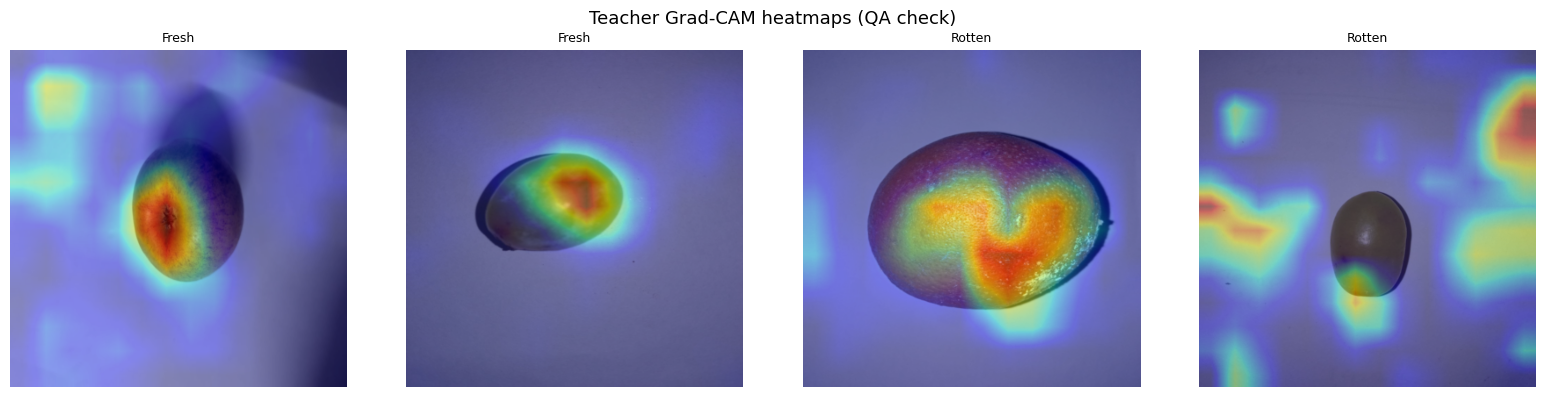

In [27]:
class BatchGradCAM:
    """Batched Grad-CAM on the last backbone block (condition head).

    Because samples in a batch are independent, backpropagating
    sum(logits[i, target_i]) yields the correct PER-SAMPLE activation
    gradients in a single backward pass — ~batch-size× faster than
    looping image-by-image.
    """
    def __init__(self, model):
        self.model = model
        self.target_layer = model.features[-1]
        self.activations = None
        self.gradients   = None
        self._fh = self.target_layer.register_forward_hook(self._save_act)
        self._bh = self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):  self.activations = out
    def _save_grad(self, m, gi, go):   self.gradients   = go[0]

    @torch.enable_grad()
    def generate_batch(self, imgs, target_classes, out_size=14):
        self.model.eval()
        imgs = imgs.to(DEVICE)
        f_logits, c_logits, _, _ = self.model(imgs)
        sel = c_logits[torch.arange(len(imgs)), target_classes.to(DEVICE)]
        self.model.zero_grad()
        sel.sum().backward()
        w   = self.gradients.mean(dim=[2, 3], keepdim=True)          # (B,C,1,1)
        cam = F.relu((w * self.activations).sum(dim=1, keepdim=True)) # (B,1,h,w)
        cam = F.interpolate(cam, size=(out_size, out_size),
                            mode='bilinear', align_corners=False).squeeze(1)
        # Per-sample min-max normalization to [0,1]
        B = cam.shape[0]
        flat = cam.view(B, -1)
        mn = flat.min(dim=1, keepdim=True).values
        mx = flat.max(dim=1, keepdim=True).values
        cam = ((flat - mn) / (mx - mn + 1e-8)).view(B, out_size, out_size)
        return cam.detach().cpu()

    def cleanup(self):
        self._fh.remove(); self._bh.remove()


def generate_heatmaps(model, base_dataset, indices, transform, desc):
    """Compute teacher Grad-CAM heatmaps for the given indices (deterministic
    transform, no augmentation). Returns float16 array (N, 14, 14) aligned
    with `indices` order."""
    ds = TransformedSubset(base_dataset, indices, transform)
    loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)
    gcam = BatchGradCAM(model)
    maps = []
    for imgs, combo, fruits, conds in tqdm(loader, desc=desc):
        cams = gcam.generate_batch(imgs, conds)
        maps.append(cams.numpy().astype(np.float16))
    gcam.cleanup()
    return np.concatenate(maps, axis=0)


HEATMAP_PATH = os.path.join(CHECKPOINT_DIR, "teacher_gradcam_heatmaps.npz")

if os.path.exists(HEATMAP_PATH):
    _hm = np.load(HEATMAP_PATH)
    train_heatmaps, val_heatmaps = _hm['train'], _hm['val']
    print(f"♻️  Loaded cached teacher heatmaps: train {train_heatmaps.shape}, val {val_heatmaps.shape}")
else:
    # Teacher = Phase-1 best model (currently loaded in `model` after
    # train_multihead restored best weights). Snapshot it so Phase 2
    # training cannot mutate the teacher.
    teacher = MultiHeadMobileNetV2(NUM_FRUITS, NUM_CONDITIONS,
                                   freeze_backbone=False).to(DEVICE)
    teacher.load_state_dict(copy.deepcopy(model.state_dict()))
    for p in teacher.parameters():
        p.requires_grad_(False)     # hooks still work; graph rebuilt in enable_grad
    # Grad-CAM needs gradients w.r.t. ACTIVATIONS, which requires the conv
    # weights to participate in autograd — so re-enable just the backbone.
    for p in teacher.features.parameters():
        p.requires_grad_(True)

    train_heatmaps = generate_heatmaps(teacher, full_dataset, train_idx,
                                       val_transform, "Teacher CAMs (train)")
    val_heatmaps   = generate_heatmaps(teacher, full_dataset, val_idx,
                                       val_transform, "Teacher CAMs (val)")
    np.savez_compressed(HEATMAP_PATH, train=train_heatmaps, val=val_heatmaps)
    del teacher
    torch.cuda.empty_cache()
    size_mb = os.path.getsize(HEATMAP_PATH) / 1024 / 1024
    print(f"✓ Teacher heatmaps saved: {HEATMAP_PATH} ({size_mb:.1f} MB)")
    print(f"  train {train_heatmaps.shape}, val {val_heatmaps.shape}")

# QA visualization: teacher CAM overlaid on 4 sample training images
_fig, _axes = plt.subplots(1, 4, figsize=(16, 4))
_mean = np.array([0.485, 0.456, 0.406]); _std = np.array([0.229, 0.224, 0.225])
_rng = np.random.RandomState(SEED)
for _ax, _i in zip(_axes, _rng.choice(len(train_idx), 4, replace=False)):
    _path, _, _, _cond = full_dataset.samples[train_idx[_i]]
    _img = val_transform(Image.open(_path).convert('RGB'))
    _np_img = (_img.permute(1, 2, 0).numpy() * _std + _mean).clip(0, 1)
    _cam = cv2.resize(train_heatmaps[_i].astype(np.float32), (IMG_SIZE, IMG_SIZE))
    _ax.imshow(_np_img); _ax.imshow(_cam, cmap='jet', alpha=0.4)
    _ax.set_title(CONDITION_NAMES[_cond], fontsize=9); _ax.axis('off')
plt.suptitle("Teacher Grad-CAM heatmaps (QA check)", fontsize=13)
plt.tight_layout(); plt.show()

# Section 16c — Attention-Aware Datasets with Paired Geometric Augmentation

Training-time flips/rotations must be applied **identically** to the image
and its cached teacher heatmap, or the distillation target becomes spatially
misaligned with the augmented input. Photometric jitter applies to the image
only (it does not move pixels).

In [28]:
import torchvision.transforms.functional as TF

class AttentionDistillDataset(Dataset):
    """
    Yields (image, combo, fruit, cond, teacher_heatmap[14×14]).

    augment=True  -> paired RandomHorizontalFlip + RandomRotation(±15°)
                     applied to BOTH image and heatmap; ColorJitter
                     (brightness=0.2, contrast=0.1 — same policy as
                     Section 9) applied to the image only.
    augment=False -> deterministic (val).
    """
    def __init__(self, base, indices, heatmaps, augment):
        assert len(indices) == len(heatmaps), "heatmaps must align with indices"
        self.base     = base
        self.indices  = list(indices)
        self.heatmaps = heatmaps
        self.augment  = augment
        self.jitter   = transforms.ColorJitter(brightness=0.2, contrast=0.1)
        self.targets       = [base.targets[i]       for i in self.indices]
        self.fruit_targets = [base.fruit_targets[i] for i in self.indices]
        self.cond_targets  = [base.cond_targets[i]  for i in self.indices]
        self.classes       = base.classes

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real = self.indices[idx]
        path, combo, fruit, cond = self.base.samples[real]
        img = Image.open(path).convert('RGB')
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        hm  = torch.from_numpy(self.heatmaps[idx].astype(np.float32)).unsqueeze(0)  # (1,14,14)

        if self.augment:
            if torch.rand(1).item() < 0.5:                       # paired h-flip
                img = TF.hflip(img)
                hm  = torch.flip(hm, dims=[-1])
            angle = float(torch.empty(1).uniform_(-15, 15))       # paired rotation
            img = TF.rotate(img, angle)
            hm  = TF.rotate(hm, angle)
            img = self.jitter(img)                                # image-only photometric

        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        return img, combo, fruit, cond, hm.squeeze(0)


# Phase-2 loaders (heatmap-aware). Sampler weights reuse the same
# 15-class balancing as Section 11 — index order is identical.
train_data_att = AttentionDistillDataset(full_dataset, train_idx, train_heatmaps, augment=True)
val_data_att   = AttentionDistillDataset(full_dataset, val_idx,   val_heatmaps,   augment=False)

sampler_att = WeightedRandomSampler(sample_weights, len(sample_weights))
train_loader_att = DataLoader(train_data_att, batch_size=BATCH_SIZE, sampler=sampler_att,
                              num_workers=2, pin_memory=True)
val_loader_att   = DataLoader(val_data_att, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, pin_memory=True)
print(f"✓ Distillation loaders ready: train {len(train_data_att)} | val {len(val_data_att)}")

✓ Distillation loaders ready: train 7107 | val 1523


# Section 17 — Phase 2: Unfreeze Backbone, Discriminative Learning Rates
30 epochs, backbone lr=1e-5, heads lr=1e-3, patience=6.

In [29]:
P2_EPOCHS   = 30
P2_PATIENCE = 5

# Three-tier discriminative learning rates per plan Step 3.4
# (v2.0 used only two tiers — now aligned):
#   early backbone  (features[:7])   1e-5   — generic edges/textures
#   middle backbone (features[7:14]) 5e-5   — object parts
#   late backbone   (features[14:])  1e-4   — task-specific color semantics
#   all heads                        1e-3   — new / distilling
P2_LR_EARLY  = 1e-5
P2_LR_MIDDLE = 5e-5
P2_LR_LATE   = 1e-4
P2_LR_HEADS  = 1e-3

model.unfreeze_backbone()
trainbl = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params after unfreeze: {trainbl:,}")

optimizer_p2 = torch.optim.Adam([
    {'params': model.features[:7].parameters(),   'lr': P2_LR_EARLY,  'weight_decay': 1e-4},
    {'params': model.features[7:14].parameters(), 'lr': P2_LR_MIDDLE, 'weight_decay': 1e-4},
    {'params': model.features[14:].parameters(),  'lr': P2_LR_LATE,   'weight_decay': 1e-4},
    {'params': model.fruit_head.parameters(),     'lr': P2_LR_HEADS,  'weight_decay': 1e-4},
    {'params': model.condition_head.parameters(), 'lr': P2_LR_HEADS,  'weight_decay': 1e-4},
    # The attention head NOW receives a real gradient (distillation MSE),
    # so including it — with weight decay — is correct in this phase.
    {'params': model.attention_head.parameters(), 'lr': P2_LR_HEADS,  'weight_decay': 1e-4},
])
scheduler_p2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2, mode='min', factor=0.5, patience=3)

# Phase 2 uses the heatmap-aware loaders -> attention loss is ACTIVE.
history_p2 = train_multihead(
    model, train_loader_att, val_loader_att, criterion,
    num_epochs=P2_EPOCHS, patience=P2_PATIENCE,
    optimizer=optimizer_p2, scheduler=scheduler_p2,
    phase=2, ckpt_mgr=ckpt_mgr)

Trainable params after unfreeze: 2,799,497

[Phase 2] Epoch 1/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.1914  Fruit: 0.985  Cond: 0.827
  Val   Loss: 0.0886  Fruit: 1.000  Cond: 0.919  Att: 0.0465/0.0343
  ⭐ New best val loss: 0.0886
  💾 Checkpoint saved: phase=2, epoch=1

[Phase 2] Epoch 2/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

...

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.0253  Fruit: 0.999  Cond: 0.985
  Val   Loss: 0.0246  Fruit: 0.998  Cond: 0.984  Att: 0.0278/0.0254
  💾 Checkpoint saved: phase=2, epoch=13

[Phase 2] Epoch 14/30
---------------------------------------------


Train:   0%|          | 0/223 [00:00<?, ?it/s]

Val:   0%|          | 0/48 [00:00<?, ?it/s]

  Train Loss: 0.0166  Fruit: 0.999  Cond: 0.992
  Val   Loss: 0.0251  Fruit: 1.000  Cond: 0.988  Att: 0.0270/0.0243
  💾 Checkpoint saved: phase=2, epoch=14
  ⏹  Early stopping at epoch 14 (no val-loss improvement for 5 epochs)

✓ Phase 2 done. Best val loss: 0.0239


# Section 18 — Training Curves

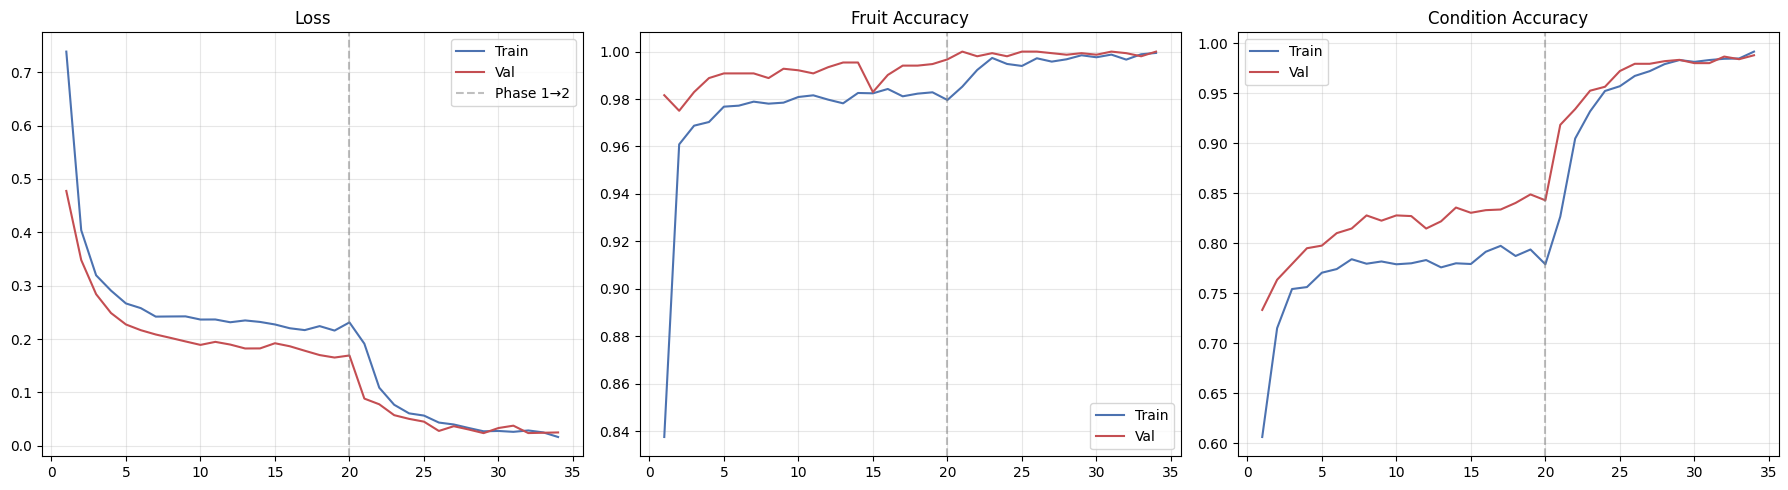

In [30]:
def plot_multihead_curves(h1, h2):
    """Plot training curves for both phases."""
    # Combine histories
    tl = h1['train_loss'] + h2['train_loss']
    vl = h1['val_loss']   + h2['val_loss']
    fa = h1['fruit_acc']  + h2['fruit_acc']
    ca = h1['cond_acc']   + h2['cond_acc']
    vfa = h1['val_fruit_acc'] + h2['val_fruit_acc']
    vca = h1['val_cond_acc']  + h2['val_cond_acc']
    epochs = range(1, len(tl)+1)
    boundary = len(h1['train_loss'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(epochs, tl, 'b-', label='Train')
    axes[0].plot(epochs, vl, 'r-', label='Val')
    axes[0].axvline(boundary, color='gray', ls='--', alpha=0.5, label='Phase 1→2')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    # Fruit accuracy
    axes[1].plot(epochs, fa, 'b-', label='Train')
    axes[1].plot(epochs, vfa, 'r-', label='Val')
    axes[1].axvline(boundary, color='gray', ls='--', alpha=0.5)
    axes[1].set_title('Fruit Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    # Condition accuracy
    axes[2].plot(epochs, ca, 'b-', label='Train')
    axes[2].plot(epochs, vca, 'r-', label='Val')
    axes[2].axvline(boundary, color='gray', ls='--', alpha=0.5)
    axes[2].set_title('Condition Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout(); plt.show()

plot_multihead_curves(history_p1, history_p2)

# Section 19 — Test Set Evaluation

Test:   0%|          | 0/48 [00:00<?, ?it/s]


TEST RESULTS
  Fruit accuracy:     0.9993 (99.9%)
  Condition accuracy: 0.9829 (98.3%)
  Combined accuracy:  0.9823 (98.2%)

--- Fruit Classification ---
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       306
      Banana       1.00      1.00      1.00       307
       Grape       1.00      1.00      1.00       301
       Mango       1.00      1.00      1.00       301
      Orange       1.00      1.00      1.00       309

    accuracy                           1.00      1524
   macro avg       1.00      1.00      1.00      1524
weighted avg       1.00      1.00      1.00      1524

--- Condition Classification ---
                precision    recall  f1-score   support

Formalin-mixed       0.98      0.99      0.98       476
         Fresh       0.99      0.97      0.98       572
        Rotten       0.97      0.99      0.98       476

      accuracy                           0.98      1524
     macro avg       0.98      0.98      

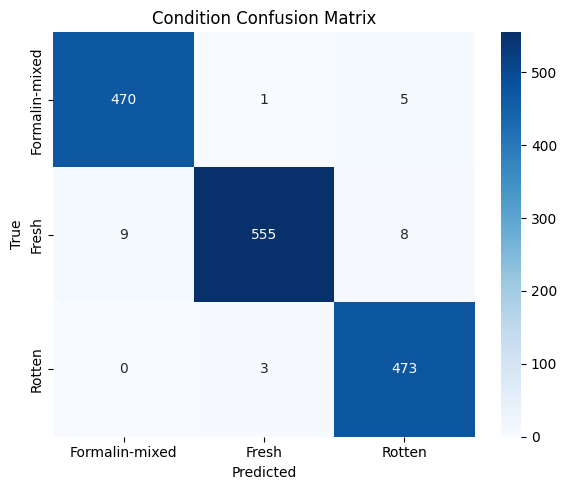

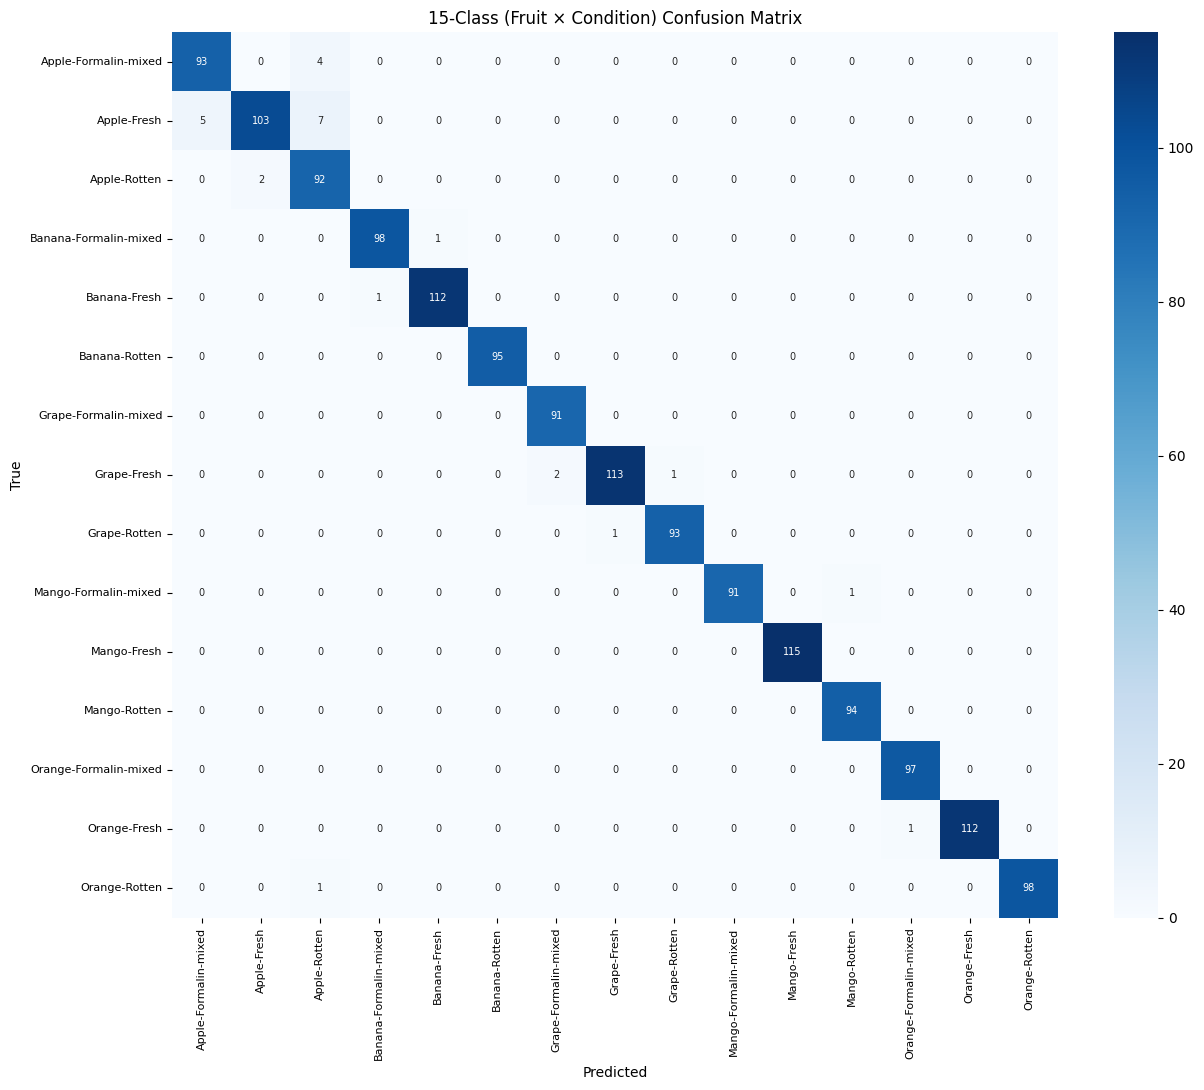

In [31]:
def evaluate_multihead(model, test_loader, class_names):
    model.eval()
    all_fruit_true, all_fruit_pred = [], []
    all_cond_true,  all_cond_pred  = [], []
    all_combo_true, all_combo_pred = [], []

    with torch.no_grad():
        for imgs, combo, fruits, conds in tqdm(test_loader, desc="Test"):
            imgs = imgs.to(DEVICE)
            f_logits, c_logits, _, _ = model(imgs)
            fp = f_logits.argmax(1).cpu().numpy()
            cp = c_logits.argmax(1).cpu().numpy()

            all_fruit_true.extend(fruits.numpy())
            all_fruit_pred.extend(fp)
            all_cond_true.extend(conds.numpy())
            all_cond_pred.extend(cp)
            all_combo_true.extend(combo.numpy())
            for fi, ci in zip(fp, cp):
                combo_name = f"{FRUIT_NAMES[fi]}-{CONDITION_NAMES[ci]}"
                if combo_name in full_dataset.class_to_idx:
                    all_combo_pred.append(full_dataset.class_to_idx[combo_name])
                else:
                    all_combo_pred.append(-1)

    ft, fpp = np.array(all_fruit_true), np.array(all_fruit_pred)
    ct, cpp = np.array(all_cond_true),  np.array(all_cond_pred)
    cbt, cbp = np.array(all_combo_true), np.array(all_combo_pred)

    fruit_acc = np.mean(ft == fpp)
    cond_acc  = np.mean(ct == cpp)
    combo_acc = np.mean(cbt == cbp)

    print(f"\n{'='*55}")
    print(f"TEST RESULTS")
    print(f"{'='*55}")
    print(f"  Fruit accuracy:     {fruit_acc:.4f} ({fruit_acc*100:.1f}%)")
    print(f"  Condition accuracy: {cond_acc:.4f} ({cond_acc*100:.1f}%)")
    print(f"  Combined accuracy:  {combo_acc:.4f} ({combo_acc*100:.1f}%)")

    print(f"\n--- Fruit Classification ---")
    print(classification_report(ft, fpp, target_names=FRUIT_NAMES))

    print(f"--- Condition Classification ---")
    print(classification_report(ct, cpp, target_names=CONDITION_NAMES))

    # ── Formalin-specific safety metrics (plan Step 3.5; missing in v2.0) ──
    F_ID = CONDITION_TO_ID["Formalin-mixed"]
    tp = np.sum((ct == F_ID) & (cpp == F_ID))
    fn = np.sum((ct == F_ID) & (cpp != F_ID))
    fp_ = np.sum((ct != F_ID) & (cpp == F_ID))
    tn = np.sum((ct != F_ID) & (cpp != F_ID))
    print("--- Formalin Detection (safety-critical) ---")
    print(f"  TPR (recall):          {tp/(tp+fn):.4f}")
    print(f"  FNR (missed formalin): {fn/(tp+fn):.4f}   <- most dangerous error")
    print(f"  FPR (false alarm):     {fp_/(fp_+tn):.4f}")
    print(f"  Precision:             {tp/max(tp+fp_,1):.4f}")

    # Condition confusion matrix (3×3)
    cm = confusion_matrix(ct, cpp)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CONDITION_NAMES, yticklabels=CONDITION_NAMES)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title('Condition Confusion Matrix')
    plt.tight_layout(); plt.show()

    # Full 15-class confusion matrix (plan "Figure 3"; missing in v2.0)
    valid = cbp >= 0
    cm15 = confusion_matrix(cbt[valid], cbp[valid],
                            labels=list(range(len(class_names))))
    plt.figure(figsize=(13, 11))
    sns.heatmap(cm15, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'size': 7})
    plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title('15-Class (Fruit × Condition) Confusion Matrix')
    plt.tight_layout(); plt.show()

    return fruit_acc, cond_acc, combo_acc, ft, fpp, ct, cpp

fruit_acc, cond_acc, combo_acc, ft, fp, ct, cp = evaluate_multihead(
    model, test_loader, full_dataset.classes)

# Section 19b — Attention Head Faithfulness Evaluation (NEW)

The trained attention head is the pipeline's single novelty claim, so it
must be *quantitatively* evaluated, not just visualized. Two tests:

1. **Agreement with post-hoc Grad-CAM** on the *final* model (Pearson &
   Spearman correlation per image, on the held-out test set). High
   correlation = the forward-pass head is a faithful, backprop-free
   substitute for Grad-CAM on-device.
2. **Deletion test** (Petsiuk et al., RISE): progressively mask the image
   regions the attention head ranks most important and measure the drop
   in the true-condition probability. A faithful map should degrade the
   prediction much faster than random masking. We report the mean
   deletion AUC (lower = more faithful) for attention vs. random.

Attention ↔ Grad-CAM agreement over 200 test images:
  Pearson  r: 0.663 ± 0.219
  Spearman ρ: 0.494 ± 0.236


Deletion test:   0%|          | 0/100 [00:00<?, ?it/s]


Deletion AUC (lower = more faithful):
  Attention-ranked masking: 0.3699
  Random masking:           0.4260
  ✓ attention beats random


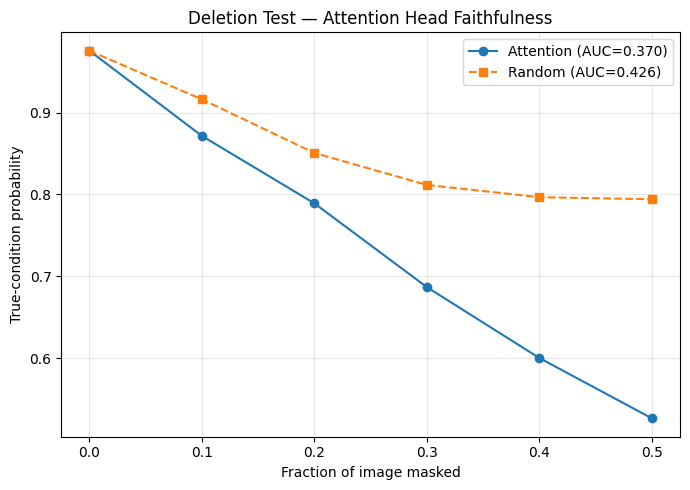

In [32]:
from scipy.stats import pearsonr, spearmanr

# NumPy 2.x removed np.trapz (renamed np.trapezoid) — compatibility shim
_trapz = getattr(np, "trapezoid", None) or getattr(np, "trapz")

N_FAITH = 200   # test images for correlation
N_DEL   = 100   # test images for deletion test (more expensive)
rng = np.random.RandomState(SEED)
faith_idx = rng.choice(len(test_data), N_FAITH, replace=False)

# ── 1. Attention vs. post-hoc Grad-CAM correlation (final model) ─────
gcam_final = BatchGradCAM(model)
pearsons, spearmans = [], []

for start in range(0, N_FAITH, 32):
    chunk = faith_idx[start:start+32]
    imgs, conds = [], []
    for i in chunk:
        img_t, combo, fruit, cond = test_data[int(i)]
        imgs.append(img_t); conds.append(cond)
    imgs  = torch.stack(imgs)
    conds = torch.tensor(conds)

    cams = gcam_final.generate_batch(imgs, conds).numpy()        # (B,14,14)
    with torch.no_grad():
        _, _, att_maps, _ = model(imgs.to(DEVICE))
    atts = att_maps.cpu().numpy()                                 # (B,14,14)

    for a, c in zip(atts, cams):
        a_f, c_f = a.flatten(), c.flatten()
        if a_f.std() > 1e-6 and c_f.std() > 1e-6:
            pearsons.append(pearsonr(a_f, c_f)[0])
            spearmans.append(spearmanr(a_f, c_f)[0])

gcam_final.cleanup()
print(f"Attention ↔ Grad-CAM agreement over {len(pearsons)} test images:")
print(f"  Pearson  r: {np.mean(pearsons):.3f} ± {np.std(pearsons):.3f}")
print(f"  Spearman ρ: {np.mean(spearmans):.3f} ± {np.std(spearmans):.3f}")

# ── 2. Deletion test: attention-ranked vs. random masking ────────────
def deletion_curve(model, img_t, cond, rank_map, steps=(0.0, 0.1, 0.2, 0.3, 0.4, 0.5)):
    """Mask top-fraction 14×14 cells (by rank_map) with the dataset-mean
    color; return true-class probability at each masking fraction."""
    cell = IMG_SIZE // 14                     # ~27 px per attention cell
    order = np.argsort(rank_map.flatten())[::-1]
    probs = []
    for frac in steps:
        k = int(frac * 196)
        img_m = img_t.clone()
        for c_idx in order[:k]:
            r, c = divmod(int(c_idx), 14)
            img_m[:, r*cell:(r+1)*cell, c*cell:(c+1)*cell] = 0.0   # 0 = mean after normalization
        with torch.no_grad():
            _, c_logits, _, _ = model(img_m.unsqueeze(0).to(DEVICE))
            probs.append(F.softmax(c_logits, dim=1)[0, cond].item())
    return np.array(probs)

steps = (0.0, 0.1, 0.2, 0.3, 0.4, 0.5)
att_curves, rnd_curves = [], []
del_idx = rng.choice(len(test_data), N_DEL, replace=False)

model.eval()
for i in tqdm(del_idx, desc="Deletion test"):
    img_t, combo, fruit, cond = test_data[int(i)]
    with torch.no_grad():
        _, _, att_map, _ = model(img_t.unsqueeze(0).to(DEVICE))
    att_np = att_map[0].cpu().numpy()
    rnd_np = rng.rand(14, 14)
    att_curves.append(deletion_curve(model, img_t, cond, att_np, steps))
    rnd_curves.append(deletion_curve(model, img_t, cond, rnd_np, steps))

att_mean = np.mean(att_curves, axis=0)
rnd_mean = np.mean(rnd_curves, axis=0)
att_auc  = float(_trapz(att_mean, steps))
rnd_auc  = float(_trapz(rnd_mean, steps))

print(f"\nDeletion AUC (lower = more faithful):")
print(f"  Attention-ranked masking: {att_auc:.4f}")
print(f"  Random masking:           {rnd_auc:.4f}")
print(f"  {'✓ attention beats random' if att_auc < rnd_auc else '⚠️ attention does NOT beat random — head is not faithful'}")

plt.figure(figsize=(7, 5))
plt.plot(steps, att_mean, 'o-', label=f'Attention (AUC={att_auc:.3f})')
plt.plot(steps, rnd_mean, 's--', label=f'Random (AUC={rnd_auc:.3f})')
plt.xlabel('Fraction of image masked'); plt.ylabel('True-condition probability')
plt.title('Deletion Test — Attention Head Faithfulness')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

attention_faithfulness = {
    'pearson_mean':  float(np.mean(pearsons)),
    'pearson_std':   float(np.std(pearsons)),
    'spearman_mean': float(np.mean(spearmans)),
    'deletion_auc_attention': att_auc,
    'deletion_auc_random':    rnd_auc,
    'n_correlation': len(pearsons),
    'n_deletion':    int(N_DEL),
}

# Section 20 — OOD Detection (Mahalanobis Distance)
Extract 1280-dim features from all training images, compute per-class centroids and shared precision matrix, and calibrate the threshold.

In [34]:
def extract_features(model, dataset, indices, transform, batch_size=64):
    """Extract 1280-dim feature vectors from the backbone."""
    subset = TransformedSubset(dataset, indices, transform)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_features = []
    all_combo    = []
    model.eval()
    with torch.no_grad():
        for imgs, combo, fruits, conds in tqdm(loader, desc="Extracting features"):
            _, _, _, feats = model(imgs.to(DEVICE))
            all_features.append(feats.cpu().numpy())
            all_combo.extend(combo.numpy())
    return np.vstack(all_features), np.array(all_combo)

# Extract training features (fit statistics on TRAIN ONLY — no leakage)
train_features, train_combo_labels = extract_features(
    model, full_dataset, train_idx, val_transform)   # val_transform = no aug
print(f"Feature matrix: {train_features.shape}")

# Per-class centroids
centroids = {}
for cls_idx, cls_name in enumerate(full_dataset.classes):
    mask = train_combo_labels == cls_idx
    if mask.sum() > 0:
        centroids[cls_name] = train_features[mask].mean(axis=0)

# Shared (tied) covariance — per-class 1280×1280 covariance from ~470
# samples/class is singular (n << d); tied covariance is the standard
# Mahalanobis-OOD formulation (Lee et al., NeurIPS 2018).
all_diffs = []
for cls_idx, cls_name in enumerate(full_dataset.classes):
    mask = train_combo_labels == cls_idx
    if mask.sum() > 0:
        all_diffs.append(train_features[mask] - centroids[cls_name])
all_diffs  = np.vstack(all_diffs)
cov_matrix = np.cov(all_diffs, rowvar=False)

reg = 1e-4 * np.eye(cov_matrix.shape[0])
precision_matrix = np.linalg.inv(cov_matrix + reg)
print(f"Centroids: {len(centroids)} classes | Precision matrix: {precision_matrix.shape}")

def mahalanobis_min(features, centroids, precision):
    """Min Mahalanobis distance to the nearest class centroid."""
    dists = np.full(len(features), np.inf)
    for cls_name, centroid in centroids.items():
        diff = features - centroid
        left = diff @ precision
        d = np.sqrt(np.maximum(np.sum(left * diff, axis=1), 0.0))
        dists = np.minimum(dists, d)
    return dists

# NOTE (v3.0): the threshold is NOT set here. v2.0 used the 99th percentile
# of TRAINING distances — a statistic of data the covariance was fitted on,
# and never validated against a single OOD sample. Section 20b calibrates
# the threshold on the held-out VALIDATION split and evaluates it against
# real negative data (AUROC, FPR@95%TPR) before anything is exported.
train_dists = mahalanobis_min(train_features, centroids, precision_matrix)
print(f"Training ID distance stats: mean={train_dists.mean():.2f}, "
      f"std={train_dists.std():.2f}, max={train_dists.max():.2f}")

Extracting features:   0%|          | 0/112 [00:00<?, ?it/s]

Feature matrix: (7107, 1280)
Centroids: 15 classes | Precision matrix: (1280, 1280)
Training ID distance stats: mean=35.02, std=3.57, max=52.31


# Section 20b — OOD Evaluation Against Real Negative Data (NEW)

**v2.0 never tested the OOD detector on a single out-of-distribution
image** — the threshold was the 99th percentile of *training* distances,
which says nothing about whether a car, a hand, or an unknown fruit is
rejected. This section:

- Builds two negative sets: **far-OOD** (CIFAR-100 natural images — cars,
  animals, furniture — resized to 384) and **near-OOD** (patch-shuffled
  fruit images: fruit textures with destroyed object structure).
- Scores **Mahalanobis** against two standard baselines: **MSP** (max
  softmax probability) and **Energy** (−logsumexp of logits), reporting
  **AUROC** and **FPR@95%TPR** for each — the standard OOD protocol.
- Calibrates the deployed threshold at **95% TPR on the *validation* ID
  split** (not training), then reports the achieved OOD rejection rates.

100%|██████████| 169001437/169001437 [46:28<00:00, 60596.14it/s]


Extracting /kaggle/working/cifar/cifar-100-python.tar.gz to /kaggle/working/cifar
✓ far-OOD set ready (1000 CIFAR-100 images)


Building near-OOD set:   0%|          | 0/1000 [00:00<?, ?it/s]

✓ near-OOD set ready (1000 patch-shuffled fruit images)


Extracting features:   0%|          | 0/24 [00:00<?, ?it/s]


Method        Negative set                 AUROC   FPR@95TPR
------------------------------------------------------------
Mahalanobis   far-OOD (CIFAR-100)         1.0000      0.0000
Mahalanobis   near-OOD (patch-shuf)       1.0000      0.0000
MSP           far-OOD (CIFAR-100)         0.9984      0.0010
MSP           near-OOD (patch-shuf)       0.6739      0.7340
Energy        far-OOD (CIFAR-100)         0.9994      0.0000
Energy        near-OOD (patch-shuf)       0.6038      0.8000

Deployed Mahalanobis threshold (95% val-ID TPR): 46.53
  far-OOD (CIFAR-100) rejection rate: 1.000
  near-OOD (patch-shuf) rejection rate: 1.000


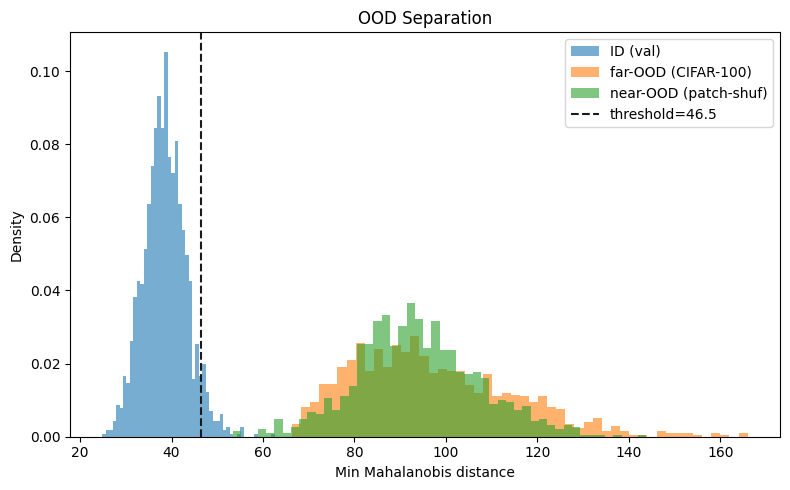


✓ OOD config saved: /kaggle/working/mobile_deploy/ood_config.json (16.8 MB)
✓ Compact OOD config: ood_config.npz (5.9 MB)


In [35]:
from sklearn.metrics import roc_auc_score

N_OOD = 1000
rng = np.random.RandomState(SEED)

ood_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def score_batch_images(pil_images):
    """Return (features, fruit_logits) for a list of PIL images."""
    feats, logits = [], []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(pil_images), 32):
            batch = torch.stack([ood_transform(im) for im in pil_images[start:start+32]]).to(DEVICE)
            f_l, c_l, _, ft = model(batch)
            feats.append(ft.cpu().numpy()); logits.append(f_l.cpu().numpy())
    return np.vstack(feats), np.vstack(logits)

ood_sets = {}   # name -> (features, fruit_logits)

# ── Negative set 1: far-OOD (CIFAR-100, resized to 384) ──────────────
# Guarded: requires internet. If the download fails, the evaluation
# continues with the near-OOD set only (and says so loudly).
try:
    import torchvision
    cifar = torchvision.datasets.CIFAR100(root='/kaggle/working/cifar',
                                          train=False, download=True)
    cifar_sel = rng.choice(len(cifar), N_OOD, replace=False)
    far_imgs = [cifar[int(i)][0] for i in cifar_sel]
    ood_sets['far-OOD (CIFAR-100)'] = score_batch_images(far_imgs)
    print(f"✓ far-OOD set ready ({N_OOD} CIFAR-100 images)")
except Exception as e:
    print(f"⚠️ CIFAR-100 unavailable ({type(e).__name__}: {e}) — "
          f"continuing with near-OOD only. Enable internet for the full evaluation.")

# ── Negative set 2: near-OOD (patch-shuffled fruit test images) ──────
def patch_shuffle(pil_img, grid=6):
    im = pil_img.resize((IMG_SIZE, IMG_SIZE))
    a  = np.array(im); s = IMG_SIZE // grid
    tiles = [a[r*s:(r+1)*s, c*s:(c+1)*s].copy() for r in range(grid) for c in range(grid)]
    rng.shuffle(tiles)
    out = np.zeros_like(a)
    for k, t in enumerate(tiles):
        r, c = divmod(k, grid)
        out[r*s:(r+1)*s, c*s:(c+1)*s] = t
    return Image.fromarray(out)

near_sel  = rng.choice(len(test_idx), min(N_OOD, len(test_idx)), replace=False)
near_imgs = [patch_shuffle(Image.open(full_dataset.samples[test_idx[int(i)]][0]).convert('RGB'))
             for i in tqdm(near_sel, desc="Building near-OOD set")]
ood_sets['near-OOD (patch-shuf)'] = score_batch_images(near_imgs)
print(f"✓ near-OOD set ready ({len(near_imgs)} patch-shuffled fruit images)")

# ── ID scores on the held-out VALIDATION split (for calibration) ─────
val_features, _ = extract_features(model, full_dataset, val_idx, val_transform)
val_loader_plain = DataLoader(TransformedSubset(full_dataset, val_idx, val_transform),
                              batch_size=64, shuffle=False, num_workers=2)
val_logits = []
model.eval()
with torch.no_grad():
    for imgs, *_ in val_loader_plain:
        f_l, _, _, _ = model(imgs.to(DEVICE))
        val_logits.append(f_l.cpu().numpy())
val_logits = np.vstack(val_logits)

# ── Score functions (higher = more OOD) ──────────────────────────────
def maha_score(feats):  return mahalanobis_min(feats, centroids, precision_matrix)
def msp_score(logits):
    p = np.exp(logits - logits.max(1, keepdims=True))
    p /= p.sum(1, keepdims=True)
    return -p.max(1)                       # negative MSP: higher = more OOD
def energy_score(logits):
    m = logits.max(1)
    return -(m + np.log(np.exp(logits - logits.max(1, keepdims=True)).sum(1)))

id_scores = {'Mahalanobis': maha_score(val_features),
             'MSP':         msp_score(val_logits),
             'Energy':      energy_score(val_logits)}

def fpr_at_95tpr(id_s, ood_s):
    thr = np.percentile(id_s, 95)                    # accept 95% of ID
    return float(np.mean(ood_s <= thr))              # OOD wrongly accepted

print(f"\n{'Method':<14}{'Negative set':<26}{'AUROC':>8}{'FPR@95TPR':>12}")
print('-' * 60)
results_ood = {}
for name, id_s in id_scores.items():
    for set_name, (of, ol) in ood_sets.items():
        ood_s = maha_score(of) if name == 'Mahalanobis' else \
                (msp_score(ol) if name == 'MSP' else energy_score(ol))
        y = np.concatenate([np.zeros(len(id_s)), np.ones(len(ood_s))])
        s = np.concatenate([id_s, ood_s])
        auroc = roc_auc_score(y, s)
        fpr95 = fpr_at_95tpr(id_s, ood_s)
        results_ood[f"{name} | {set_name}"] = {'auroc': float(auroc), 'fpr@95tpr': fpr95}
        print(f"{name:<14}{set_name:<26}{auroc:>8.4f}{fpr95:>12.4f}")

# ── Deployed threshold: 95% TPR on VALIDATION ID distances ───────────
threshold = float(np.percentile(id_scores['Mahalanobis'], 95))
print(f"\nDeployed Mahalanobis threshold (95% val-ID TPR): {threshold:.2f}")
for set_name, (of, _) in ood_sets.items():
    rej = float(np.mean(maha_score(of) > threshold))
    print(f"  {set_name} rejection rate: {rej:.3f}")

# ── Distance histogram (plan Figure 5) ───────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(id_scores['Mahalanobis'], bins=50, alpha=0.6, label='ID (val)', density=True)
for set_name, (of, _) in ood_sets.items():
    plt.hist(maha_score(of), bins=50, alpha=0.6, label=set_name, density=True)
plt.axvline(threshold, color='k', ls='--', label=f'threshold={threshold:.1f}')
plt.xlabel('Min Mahalanobis distance'); plt.ylabel('Density')
plt.title('OOD Separation'); plt.legend(); plt.tight_layout(); plt.show()

# ── Save OOD config (validated threshold) ────────────────────────────
ood_config = {
    'algorithm': 'Mahalanobis Distance (tied covariance)',
    'threshold': threshold,
    'threshold_calibration': '95% TPR on held-out validation split',
    'evaluation': results_ood,
    'centroids': {k: np.round(v, 4).tolist() for k, v in centroids.items()},
    'precision_matrix': np.round(precision_matrix, 6).tolist(),
    'normalization': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]},
    'input_size': IMG_SIZE,
}
ood_path = os.path.join(EXPORT_DIR, 'ood_config.json')
with open(ood_path, 'w') as f:
    json.dump(ood_config, f)
print(f"\n✓ OOD config saved: {ood_path} ({os.path.getsize(ood_path)/1024/1024:.1f} MB)")

# Compact binary copy for mobile (JSON precision matrices are huge)
np.savez_compressed(os.path.join(EXPORT_DIR, 'ood_config.npz'),
                    threshold=np.array([threshold]),
                    centroids=np.stack([centroids[c] for c in full_dataset.classes]).astype(np.float32),
                    class_order=np.array(full_dataset.classes),
                    precision=precision_matrix.astype(np.float32))
print(f"✓ Compact OOD config: ood_config.npz "
      f"({os.path.getsize(os.path.join(EXPORT_DIR, 'ood_config.npz'))/1024/1024:.1f} MB)")

# Section 21 — Grad-CAM Explainability Visualisation

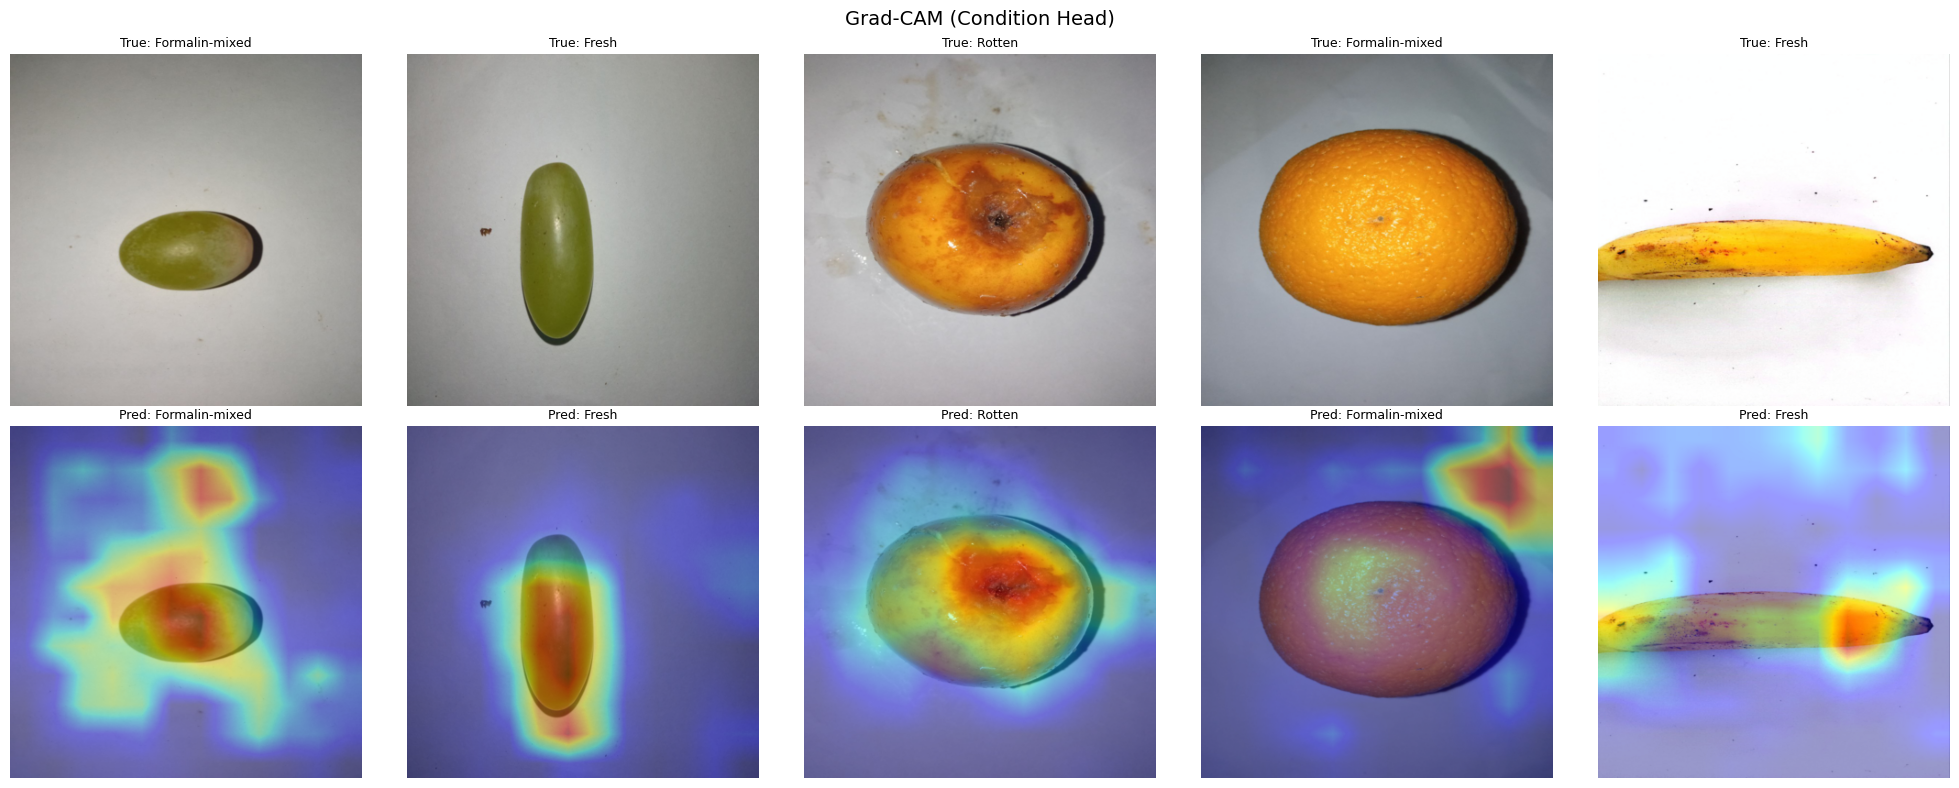

In [37]:
class GradCAM:
    """Grad-CAM for MultiHeadMobileNetV2 backbone."""
    def __init__(self, model):
        self.model = model
        self.target_layer = model.features[-1]
        self.gradients  = None
        self.activations = None
        self._fh = self.target_layer.register_forward_hook(self._save_act)
        self._bh = self.target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, inp, out):
        self.activations = out.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def generate(self, input_tensor, head='fruit', target_class=None):
        self.model.eval()
        f_logits, c_logits, _, _ = self.model(input_tensor)
        logits = f_logits if head == 'fruit' else c_logits
        if target_class is None:
            target_class = logits.argmax(dim=1).item()
        self.model.zero_grad()
        logits[0, target_class].backward()
        w   = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((w * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

    def cleanup(self):
        self._fh.remove()
        self._bh.remove()


def show_gradcam(model, dataset, n=4):
    gcam = GradCAM(model)
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    for col, idx in enumerate(indices):
        img_t, combo, fruit, cond = dataset[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)
        cam, pred = gcam.generate(inp, head='condition')
        img_np = (img_t.permute(1,2,0).numpy() * std + mean).clip(0, 1)

        axes[0, col].imshow(img_np)
        axes[0, col].set_title(f"True: {CONDITION_NAMES[cond]}", fontsize=9)
        axes[0, col].axis('off')

        axes[1, col].imshow(img_np)
        axes[1, col].imshow(cam, cmap='jet', alpha=0.4)
        axes[1, col].set_title(f"Pred: {CONDITION_NAMES[pred]}", fontsize=9)
        axes[1, col].axis('off')

    gcam.cleanup()
    plt.suptitle("Grad-CAM (Condition Head)", fontsize=14)
    plt.tight_layout(); plt.show()

show_gradcam(model, test_data, n=5)